## Load CPI Data

To begin, we need to load the CPI data from your Google Drive. First, run the cell below to mount your Google Drive. After it's successfully mounted, you'll need to provide the full path to your `Indicador.xls` file.

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Once Google Drive is mounted, replace `'YOUR_FILE_PATH'` below with the actual path to your `Indicador.xls` file. For example, if it's directly in 'My Drive', the path might be `/content/drive/MyDrive/Indicador.xls`.

In [7]:
# Re-read the Excel file, skipping the first 3 rows
cpi_df = pd.read_excel('/content/drive/MyDrive/colab/Indicador.xls', skiprows=3)

# Display the first few rows of the cleaned DataFrame
display(cpi_df.head())

ERROR: No se encontró el archivo en: /content/drive/MyDrive/colab/Indicador.xls
Por favor, asegúrate de que Google Drive esté montado correctamente y que la carpeta 'colab' contenga el archivo.


In [ ]:
# Convert 'Mes' column to datetime objects
cpi_df['Mes'] = pd.to_datetime(cpi_df['Mes'])

# Display DataFrame info to verify data types
print(cpi_df.info())

# Display the head to see the effect of the conversion
display(cpi_df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 364 entries, 0 to 363
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Mes     364 non-null    datetime64[ns]
 1   Valor   364 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 5.8 KB
None


,Mes,Valor
0,1996-01-01,0.3
1,1996-02-01,0.5
2,1996-03-01,0.7
3,1996-04-01,1.0
4,1996-05-01,0.8


In [ ]:
import pandas as pd

# Rename columns for clarity
cpi_df = cpi_df.rename(columns={'Mes': 'Date', 'Valor': 'Monthly_Percentage_Change'})

In [ ]:
# Set 'Date' as the index
cpi_df = cpi_df.set_index('Date')

Now, let's convert the `Monthly_Percentage_Change` into a cumulative CPI index. We'll set the CPI for the first month in the dataset to 100. If you wish to use a different base month, you can modify the `base_date` and `base_cpi_value` variables below.

In [ ]:
# Convert monthly percentage change to a cumulative CPI index
# The 'Valor' column represents monthly percentage change (e.g., 0.3 means 0.3%)

# Convert percentage to a factor (e.g., 0.3% -> 1.003)
cpi_df['Factor'] = 1 + (cpi_df['Monthly_Percentage_Change'] / 100)

# Choose a base period for the CPI index. By default, using the first month.
# You can change this to any specific date in your dataset.
base_date = cpi_df.index.min() # Or pd.to_datetime('YYYY-MM-DD') for a specific date
base_cpi_value = 100.0 # CPI at the base date

# Initialize a list to store the cumulative CPI
cumulative_cpi = []
current_cpi = base_cpi_value

# Iterate through the factors to calculate the cumulative CPI
for date, factor in cpi_df['Factor'].items():
    if date == base_date:
        cumulative_cpi.append(base_cpi_value)
    else:
        # Find the previous month's CPI to calculate current month's CPI
        # This logic ensures correct calculation even if base_date is not the very first date
        prev_month_factor = cpi_df.loc[cpi_df.index < date, 'Factor'].iloc[-1] if not cumulative_cpi else cpi_df.loc[cpi_df.index == date - pd.DateOffset(months=1), 'Factor'].iloc[0]

        # More robust way using `cumprod` and then adjusting:
        cpi_df['CPI_Index'] = cpi_df['Factor'].cumprod() * (base_cpi_value / cpi_df.loc[base_date, 'Factor'].cumprod())
        break # Exit loop as CPI_Index is calculated for all rows

# If the loop did not execute (e.g., only one row or base_date is the only date)
if 'CPI_Index' not in cpi_df.columns:
    # This handles the case where base_date is the first date
    cpi_df['CPI_Index'] = cpi_df['Factor'].cumprod() * base_cpi_value / cpi_df.loc[cpi_df.index.min(), 'Factor']

# Drop the 'Factor' and 'Monthly_Percentage_Change' columns as they are no longer needed for the index
cpi_df = cpi_df.drop(columns=['Factor', 'Monthly_Percentage_Change'])

# Display the updated DataFrame with the cumulative CPI index
display(cpi_df.head())

,CPI_Index
Date,
1996-01-01,100.000000
1996-02-01,100.500000
1996-03-01,101.203500
1996-04-01,102.215535
1996-05-01,103.033259


In [ ]:
# Display DataFrame info to verify data types
print(cpi_df.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 364 entries, 1996-01-01 to 2026-04-01
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   CPI_Index  364 non-null    float64
dtypes: float64(1)
memory usage: 13.8 KB
None


## Load Livestock Price Data

Now, let's load the main livestock price data from the `SerieTiempoBovinoConsumo.xls` file.

In [ ]:
import os

file_path = '/content/drive/MyDrive/colab/SerieTiempoBovinoConsumo.xlsx'

# Check if the file exists using Python's os module
if os.path.exists(file_path):
    print(f"File found at: {file_path}. Attempting to load...")
    # Load the livestock price data Excel file, without skipping initial rows
    livestock_df = pd.read_excel(file_path, header=0)

    # Display the first few rows of the cleaned livestock DataFrame
    display(livestock_df.head())
else:
    print(f"Error: File not found at the specified path: {file_path}")
    print("Please ensure the file name and path are correct. You can also re-list your drive contents to confirm.")

File found at: /content/drive/MyDrive/colab/SerieTiempoBovinoConsumo.xlsx. Attempting to load...


,Unnamed: 0,Año,Ene,Feb,Mar,Abr,May,Jun,Jul,Ago,Sep,Oct,Nov,Dic,Prom
0,NaN,1996,1291.72,1468.48,1405.64,1358.48,1318.20,1290.59,1251.31,1328.57,1360.32,1263.56,1138.51,1066.01,1295.11
1,NaN,1997,1014.64,1156.52,1078.89,1044.16,1126.27,1194.65,1333.59,1531.61,1601.15,1348.65,1220.64,1205.38,1238.01
2,NaN,1998,1227.19,1202.29,1248.61,1335.72,1357.27,1414.37,1405.75,1344.70,1310.15,1216.75,1129.51,1064.51,1271.40
3,NaN,1999,1096.04,1041.63,1114.62,1106.64,1089.88,1133.89,1159.15,1228.84,1275.74,1364.13,1158.26,1129.11,1158.16
4,NaN,2000,1150.90,1172.71,1121.45,1105.69,1084.37,1122.95,1186.43,1275.13,1327.00,1392.49,1194.11,1100.85,1186.17


In [ ]:
# Drop the 'Unnamed: 0' column as it contains no useful information
livestock_df = livestock_df.drop(columns=['Unnamed: 0'])

# Display the DataFrame head to confirm the column has been dropped
display(livestock_df.head())

,Año,Ene,Feb,Mar,Abr,May,Jun,Jul,Ago,Sep,Oct,Nov,Dic,Prom
0,1996,1291.72,1468.48,1405.64,1358.48,1318.20,1290.59,1251.31,1328.57,1360.32,1263.56,1138.51,1066.01,1295.11
1,1997,1014.64,1156.52,1078.89,1044.16,1126.27,1194.65,1333.59,1531.61,1601.15,1348.65,1220.64,1205.38,1238.01
2,1998,1227.19,1202.29,1248.61,1335.72,1357.27,1414.37,1405.75,1344.70,1310.15,1216.75,1129.51,1064.51,1271.40
3,1999,1096.04,1041.63,1114.62,1106.64,1089.88,1133.89,1159.15,1228.84,1275.74,1364.13,1158.26,1129.11,1158.16
4,2000,1150.90,1172.71,1121.45,1105.69,1084.37,1122.95,1186.43,1275.13,1327.00,1392.49,1194.11,1100.85,1186.17


## Load Historical Dollar Price Data

Now, let's load the historical dollar price data. Please make sure the `DolarHistorico.xlsx` file is in the specified path.

In [ ]:
import os
import pandas as pd

# Assuming the dollar price data is in 'DolarHistorico.xlsx' in the same folder
dolar_file_path = '/content/drive/MyDrive/colab/DolarHistorico.xlsm'
# Check if the file exists
if os.path.exists(dolar_file_path):
    print(f"File found at: {dolar_file_path}. Attempting to load...")
    # Load the dollar price data Excel file
    dolar_df = pd.read_excel(dolar_file_path, header=0)

    # Display the first few rows of the DataFrame
    display(dolar_df.head())
else:
    print(f"Error: File not found at the specified path: {dolar_file_path}")
    print("Please ensure the file name and path are correct.")

File found at: /content/drive/MyDrive/colab/DolarHistorico.xlsm. Attempting to load...


,Periodo,1. Dólar observado
0,1996-01-01,408.531818
1,1996-02-01,410.965714
2,1996-03-01,411.546667
3,1996-04-01,408.424762
4,1996-05-01,406.230476


## Prepare Dollar Price Data

Now, let's clean and prepare the `dolar_df` by converting the 'Periodo' column to datetime and renaming the columns for consistency.

In [ ]:
# Convert 'Periodo' column to datetime objects
dolar_df['Periodo'] = pd.to_datetime(dolar_df['Periodo'])

# Rename columns for clarity
dolar_df = dolar_df.rename(columns={'Periodo': 'Date', '1. Dólar observado': 'Observed_Dollar_Price'})

# Set 'Date' as the index
dolar_df = dolar_df.set_index('Date')

# Display DataFrame info to verify data types and index
print(dolar_df.info())

# Display the head to see the effect of the conversion and renaming
display(dolar_df.head())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 360 entries, 1996-01-01 to 2025-12-01
Data columns (total 1 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Observed_Dollar_Price  360 non-null    float64
dtypes: float64(1)
memory usage: 5.6 KB
None


,Observed_Dollar_Price
Date,
1996-01-01,408.531818
1996-02-01,410.965714
1996-03-01,411.546667
1996-04-01,408.424762
1996-05-01,406.230476


## Prepare Livestock Price Data

Now, let's process the `livestock_df` to ensure its 'Fecha' column is a datetime object and set it as the index, along with renaming columns for better readability and consistency with other DataFrames.

In [ ]:
import os
import pandas as pd # Ensure pandas is imported

# Code to load livestock_df, making this cell self-contained
file_path = '/content/drive/MyDrive/colab/SerieTiempoBovinoConsumo.xlsx'
if os.path.exists(file_path):
    print(f"File found at: {file_path}. Attempting to load livestock data...")
    livestock_df = pd.read_excel(file_path, header=0)
    # Drop the 'Unnamed: 0' column as it contains no useful information, if it exists
    if 'Unnamed: 0' in livestock_df.columns:
        livestock_df = livestock_df.drop(columns=['Unnamed: 0'])
else:
    print(f"Error: File not found at the specified path: {file_path}. Please check your Drive.")
    raise FileNotFoundError(f"File not found: {file_path}")

# List of month columns (in Spanish)
month_cols = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

# Melt the DataFrame to transform month columns into rows
livestock_df_melted = livestock_df.melt(
    id_vars=['Año'],
    value_vars=month_cols,
    var_name='Month_Abbr',
    value_name='Steer_Price'
)

# Create a mapping for Spanish month abbreviations to numerical months
month_map = {
    'Ene': 1, 'Feb': 2, 'Mar': 3, 'Abr': 4, 'May': 5, 'Jun': 6,
    'Jul': 7, 'Ago': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dic': 12
}
livestock_df_melted['Month'] = livestock_df_melted['Month_Abbr'].map(month_map)

# Combine 'Año' and 'Month' to create a 'Date' column
livestock_df_melted['Date'] = pd.to_datetime(
    livestock_df_melted['Año'].astype(str) + '-' + livestock_df_melted['Month'].astype(str) + '-01'
)

# Set 'Date' as the index and sort it
livestock_df = livestock_df_melted.set_index('Date').sort_index()

# Drop auxiliary columns
livestock_df = livestock_df.drop(columns=['Año', 'Month_Abbr', 'Month'])

# Display DataFrame info to verify data types and index
print(livestock_df.info())

# Display the head to see the effect of the conversion and renaming
display(livestock_df.head())

File found at: /content/drive/MyDrive/colab/SerieTiempoBovinoConsumo.xlsx. Attempting to load livestock data...
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 360 entries, 1996-01-01 to 2025-12-01
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Steer_Price  360 non-null    float64
dtypes: float64(1)
memory usage: 5.6 KB
None


,Steer_Price
Date,
1996-01-01,1291.72
1996-02-01,1468.48
1996-03-01,1405.64
1996-04-01,1358.48
1996-05-01,1318.20


## Merge All DataFrames

Now that `cpi_df`, `dolar_df`, and `livestock_df` are all prepared with a 'Date' index, let's merge them into a single DataFrame for comprehensive analysis. We will use an outer join to ensure all dates are preserved.

In [ ]:
import os
import pandas as pd

# --- Re-create cpi_df to ensure it's available for merging ---
# Define CPI file path
cpi_file_path = '/content/drive/MyDrive/colab/Indicador.xls'

# Load the CPI data
if os.path.exists(cpi_file_path):
    print(f"File found at: {cpi_file_path}. Attempting to load CPI data...")
    cpi_df = pd.read_excel(cpi_file_path, skiprows=3)
else:
    print(f"Error: CPI file not found at: {cpi_file_path}")
    raise FileNotFoundError(f"CPI file not found: {cpi_file_path}")

# Convert 'Mes' column to datetime objects
cpi_df['Mes'] = pd.to_datetime(cpi_df['Mes'])

# Rename columns for clarity
cpi_df = cpi_df.rename(columns={'Mes': 'Date', 'Valor': 'Monthly_Percentage_Change'})

# Set 'Date' as the index
cpi_df = cpi_df.set_index('Date')

# Convert monthly percentage change to a cumulative CPI index
cpi_df['Factor'] = 1 + (cpi_df['Monthly_Percentage_Change'] / 100)

base_cpi_value = 100.0
cpi_df['CPI_Index'] = cpi_df['Factor'].cumprod() * base_cpi_value / cpi_df.loc[cpi_df.index.min(), 'Factor']

# Drop auxiliary columns
cpi_df = cpi_df.drop(columns=['Factor', 'Monthly_Percentage_Change'])

print("CPI data prepared successfully.")

# Merge cpi_df and dolar_df first
merged_df = pd.merge(cpi_df, dolar_df, on='Date', how='outer')

# Then merge the result with livestock_df
merged_df = pd.merge(merged_df, livestock_df, on='Date', how='outer')

# Sort the DataFrame by date index
merged_df = merged_df.sort_index()

# Display DataFrame info to verify the merged structure and non-null counts
print("\nMerged DataFrame Info:")
print(merged_df.info())

# Display the head of the merged DataFrame
print("\nHead of Merged DataFrame:")
display(merged_df.head())

File found at: /content/drive/MyDrive/colab/Indicador.xls. Attempting to load CPI data...
CPI data prepared successfully.

Merged DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 364 entries, 1996-01-01 to 2026-04-01
Data columns (total 3 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   CPI_Index              364 non-null    float64
 1   Observed_Dollar_Price  360 non-null    float64
 2   Steer_Price            360 non-null    float64
dtypes: float64(3)
memory usage: 11.4 KB
None

Head of Merged DataFrame:


,CPI_Index,Observed_Dollar_Price,Steer_Price
Date,,,
1996-01-01,100.000000,408.531818,1291.72
1996-02-01,100.500000,410.965714,1468.48
1996-03-01,101.203500,411.546667,1405.64
1996-04-01,102.215535,408.424762,1358.48
1996-05-01,103.033259,406.230476,1318.20


In [ ]:
# Drop the 'CPI_Index' column from merged_df
if 'CPI_Index' in merged_df.columns:
    merged_df = merged_df.drop(columns=['CPI_Index'])
    print("CPI_Index column successfully removed from merged_df.")
else:
    print("CPI_Index column not found in merged_df.")

# Display the head and info of the modified DataFrame
print("\nModified Merged DataFrame Info:")
print(merged_df.info())

print("\nHead of Modified Merged DataFrame:")
display(merged_df.head())

CPI_Index column successfully removed from merged_df.

Modified Merged DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 364 entries, 1996-01-01 to 2026-04-01
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Observed_Dollar_Price  360 non-null    float64
 1   Steer_Price            360 non-null    float64
dtypes: float64(2)
memory usage: 8.5 KB
None

Head of Modified Merged DataFrame:


,Observed_Dollar_Price,Steer_Price
Date,,
1996-01-01,408.531818,1291.72
1996-02-01,410.965714,1468.48
1996-03-01,411.546667,1405.64
1996-04-01,408.424762,1358.48
1996-05-01,406.230476,1318.20


In [ ]:
# Fill missing values in the merged_df to create merged_df_filled
# This step was originally performed before feature engineering.
print("Missing values before imputation (merged_df):")
print(merged_df.isnull().sum())

merged_df_filled = merged_df.ffill()

print("\nMissing values after imputation (merged_df_filled):")
print(merged_df_filled.isnull().sum())

# Display the head of the filled DataFrame
display(merged_df_filled.head())

Missing values before imputation (merged_df):
Observed_Dollar_Price    4
Steer_Price              4
dtype: int64

Missing values after imputation (merged_df_filled):
Observed_Dollar_Price    0
Steer_Price              0
dtype: int64


,Observed_Dollar_Price,Steer_Price
Date,,
1996-01-01,408.531818,1291.72
1996-02-01,410.965714,1468.48
1996-03-01,411.546667,1405.64
1996-04-01,408.424762,1358.48
1996-05-01,406.230476,1318.20


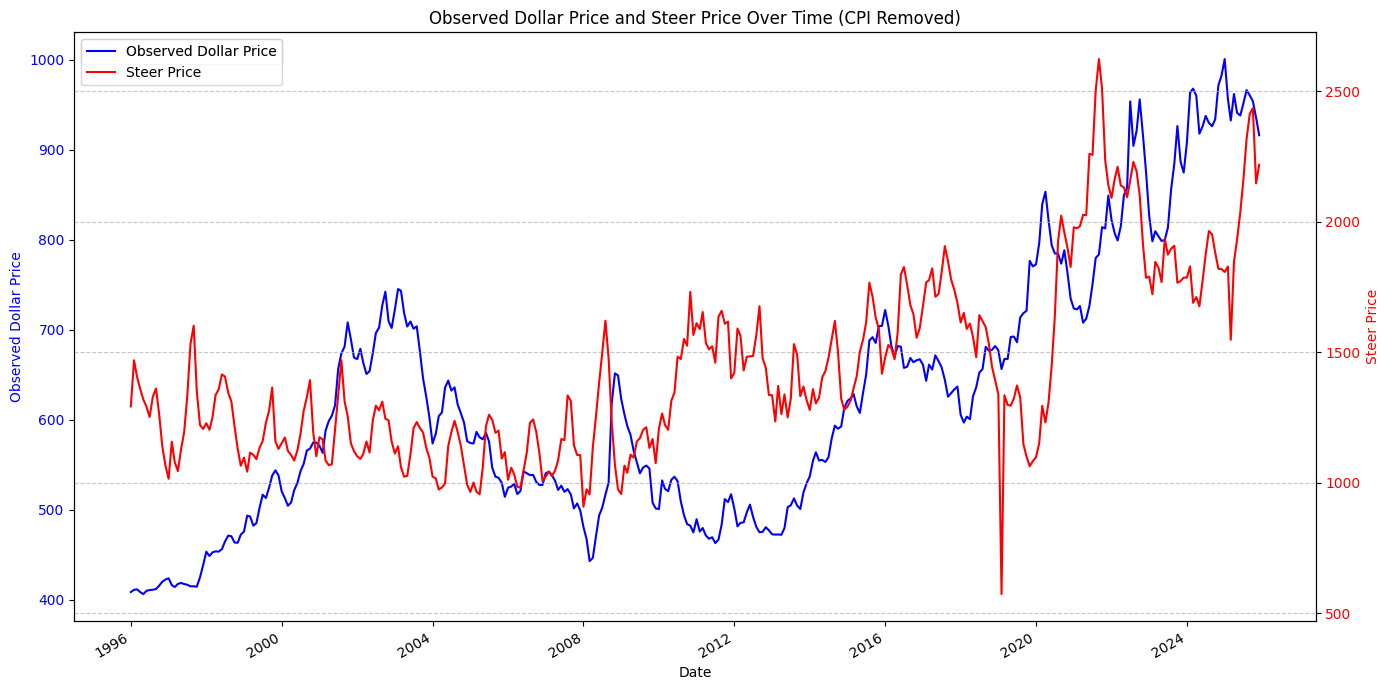

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure and a set of subplots
fig, ax1 = plt.subplots(figsize=(14, 7))

# Plot Observed_Dollar_Price on the first y-axis
sns.lineplot(x=merged_df.index, y='Observed_Dollar_Price', data=merged_df, ax=ax1, color='blue', label='Observed Dollar Price')
ax1.set_xlabel('Date')
ax1.set_ylabel('Observed Dollar Price', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Create a second y-axis for Steer_Price
ax2 = ax1.twinx()
sns.lineplot(x=merged_df.index, y='Steer_Price', data=merged_df, ax=ax2, color='red', label='Steer Price')
ax2.set_ylabel('Steer Price', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Add title and grid
plt.title('Observed Dollar Price and Steer Price Over Time (CPI Removed)')
fig.autofmt_xdate() # Rotate x-axis labels for better readability
plt.grid(True, linestyle='--', alpha=0.7)

# Add legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

In [ ]:
# @title step_artifacts
num_fig = "3" # @param {type:"string"}
step = 'DataExploration'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "Summary"] {type:"string"}
# upload_plt_to_gcs(num_fig, step, fig)

## Prepare Data for Modeling

Before building a model, we need to prepare the data. This often involves handling missing values, creating new features, and splitting the data into training and testing sets.

### Original Feature Engineering

Let's apply the original feature engineering that yielded better results. This includes creating lag features for the previous month's steer and dollar prices, 3-month rolling means, and time-based features (month, year, day of week).

In [ ]:
# Start with the DataFrame that includes vacas and maiz prices
# Create a copy to avoid modifying the original merged_df_with_vacas_maiz directly for this specific feature set
df_for_original_features = merged_df_with_vacas_maiz.copy()

# Create lag features for 'Steer_Price', 'Observed_Dollar_Price', 'Vacas_Price', and 'Maiz_Price'
# Lag 1 means the value from the previous month
df_for_original_features['Steer_Price_Lag1'] = df_for_original_features['Steer_Price'].shift(1)
df_for_original_features['Observed_Dollar_Price_Lag1'] = df_for_original_features['Observed_Dollar_Price'].shift(1)
df_for_original_features['Vacas_Price_Lag1'] = df_for_original_features['Vacas_Price'].shift(1)
df_for_original_features['Maiz_Price_Lag1'] = df_for_original_features['Maiz_Price'].shift(1) # New feature

# Create rolling mean features (e.g., 3-month rolling mean)
df_for_original_features['Steer_Price_RollMean3'] = df_for_original_features['Steer_Price'].rolling(window=3).mean().shift(1)
df_for_original_features['Observed_Dollar_Price_RollMean3'] = df_for_original_features['Observed_Dollar_Price'].rolling(window=3).mean().shift(1)
df_for_original_features['Vacas_Price_RollMean3'] = df_for_original_features['Vacas_Price'].rolling(window=3).mean().shift(1)
df_for_original_features['Maiz_Price_RollMean3'] = df_for_original_features['Maiz_Price'].rolling(window=3).mean().shift(1) # New feature

# Create time-based features
df_for_original_features['Month'] = df_for_original_features.index.month
df_for_original_features['Year'] = df_for_original_features.index.year
df_for_original_features['DayOfWeek'] = df_for_original_features.index.dayofweek # Monday=0, Sunday=6

# Drop rows with NaN values resulting from lag/rolling features
merged_df_features = df_for_original_features.dropna()

print("DataFrame with original features (including Vacas and Maiz Price) and no NaNs:")
print(merged_df_features.info())
display(merged_df_features.head())

DataFrame with original features (including Vacas and Maiz Price) and no NaNs:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 249 entries, 2005-04-01 to 2025-12-01
Data columns (total 15 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Observed_Dollar_Price            249 non-null    float64
 1   Steer_Price                      249 non-null    float64
 2   Steer_Price_Lag1                 249 non-null    float64
 3   Observed_Dollar_Price_Lag1       249 non-null    float64
 4   Steer_Price_RollMean3            249 non-null    float64
 5   Observed_Dollar_Price_RollMean3  249 non-null    float64
 6   Month                            249 non-null    int32  
 7   Year                             249 non-null    int32  
 8   DayOfWeek                        249 non-null    int32  
 9   Vacas_Price                      249 non-null    float64
 10  Maiz_Price                       249 non-null   

,Observed_Dollar_Price,Steer_Price,Steer_Price_Lag1,Observed_Dollar_Price_Lag1,Steer_Price_RollMean3,Observed_Dollar_Price_RollMean3,Month,Year,DayOfWeek,Vacas_Price,Maiz_Price,Vacas_Price_Lag1,Maiz_Price_Lag1,Vacas_Price_RollMean3,Maiz_Price_RollMean3
Date,,,,,,,,,,,,,,,
2005-04-01,580.455714,955.36,965.24,586.482727,976.576667,578.062084,4,2005,4,745.72,232.48,740.89,246.48,736.093333,236.803333
2005-05-01,578.309048,1056.74,955.36,580.455714,973.650000,580.174147,5,2005,6,778.11,227.58,745.72,232.48,741.823333,236.536667
2005-06-01,585.473333,1215.57,1056.74,578.309048,992.446667,581.749163,6,2005,2,770.33,234.05,778.11,227.58,754.906667,235.513333
2005-07-01,575.766190,1259.81,1215.57,585.473333,1075.890000,581.412698,7,2005,4,900.98,251.06,770.33,234.05,764.720000,231.370000
2005-08-01,546.609545,1240.38,1259.81,575.766190,1177.373333,579.849524,8,2005,0,922.09,233.56,900.98,251.06,816.473333,237.563333


### Original Data Split

Now, we'll re-split the data into training and testing sets using these original features.

In [ ]:
from sklearn.model_selection import train_test_split

# Define the target variable (what we want to predict)
y = merged_df_features['Steer_Price']

# Define the features (variables used for prediction)
X = merged_df_features.drop(columns=['Steer_Price'])

# Determine the split point (e.g., 80% for training, 20% for testing)
split_point = int(len(X) * 0.8)

X_train, X_test = X.iloc[:split_point], X.iloc[split_point:]
y_train, y_test = y.iloc[:split_point], y.iloc[split_point:]

print(f"Training set size: {len(X_train)} samples")
print(f"Testing set size: {len(X_test)} samples")

# Display the first few rows of the training and testing sets
print("\nX_train head:")
display(X_train.head())
print("\ny_train head:")
display(y_train.head())

Training set size: 288 samples
Testing set size: 73 samples

X_train head:


,Observed_Dollar_Price,Steer_Price_Lag1,Observed_Dollar_Price_Lag1,Steer_Price_RollMean3,Observed_Dollar_Price_RollMean3,Month,Year,DayOfWeek
Date,,,,,,,,
1996-04-01,408.424762,1405.64,411.546667,1388.613333,410.348066,4,1996,0
1996-05-01,406.230476,1358.48,408.424762,1410.866667,410.312381,5,1996,2
1996-06-01,409.846842,1318.20,406.230476,1360.773333,408.733968,6,1996,5
1996-07-01,410.723043,1290.59,409.846842,1322.423333,408.167360,7,1996,0
1996-08-01,411.100476,1251.31,410.723043,1286.700000,408.933454,8,1996,3



y_train head:


,Steer_Price
Date,
1996-04-01,1358.48
1996-05-01,1318.20
1996-06-01,1290.59
1996-07-01,1251.31
1996-08-01,1328.57


## Re-train Original Regression Model

Now that our data is prepared with the original features, let's re-train the Random Forest Regressor.

Training the original Random Forest Regressor model...
Model training complete.

Model Evaluation on Test Set (Original Features):
Mean Squared Error (MSE): 107331.96
Root Mean Squared Error (RMSE): 327.62
R-squared (R2): -0.60


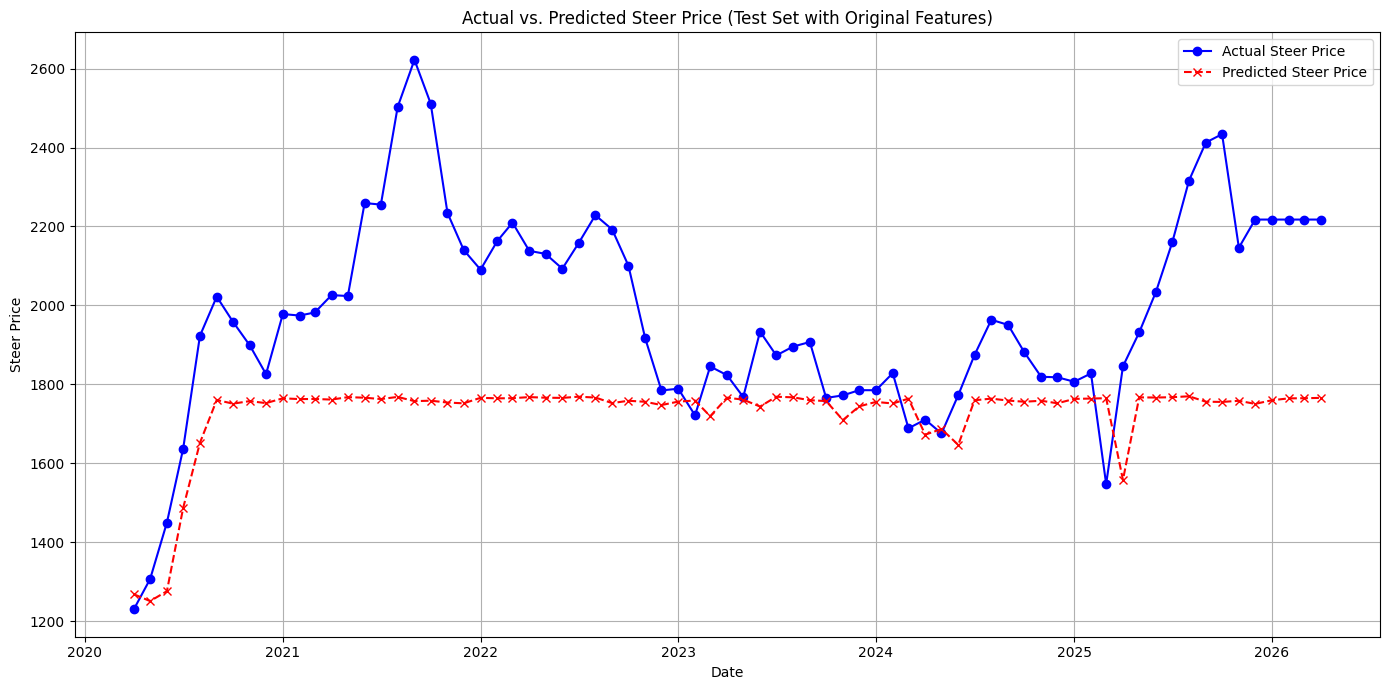

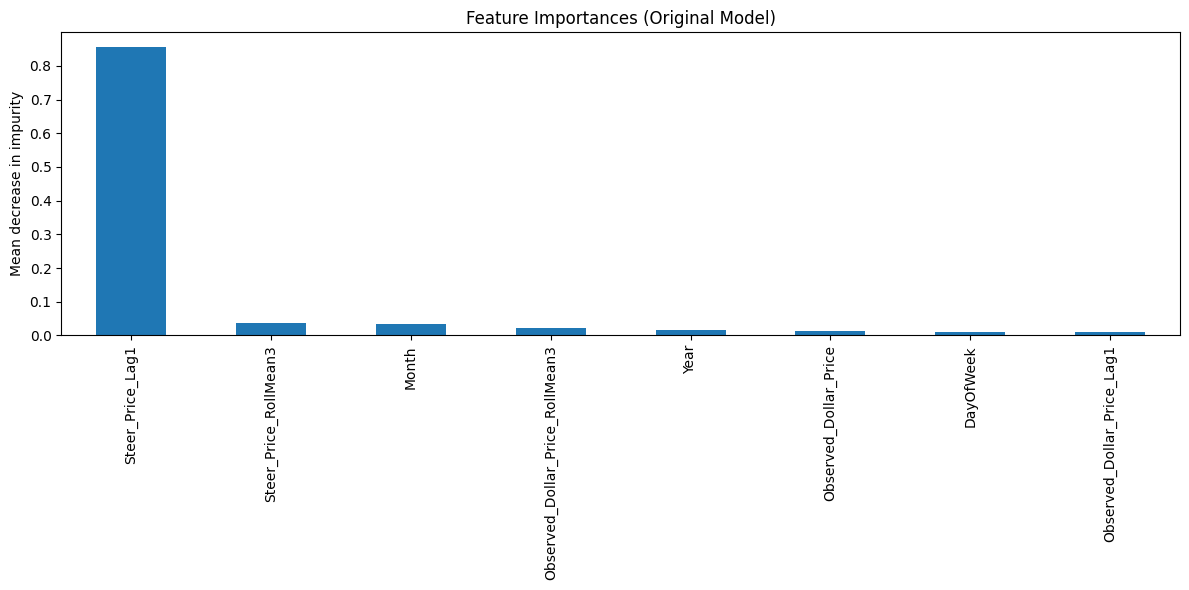

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd # Ensure pandas is imported for pd.Series

# Initialize the Random Forest Regressor model
# Using the same parameters as before
model_original = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1) # n_jobs=-1 uses all available processors

print("Training the original Random Forest Regressor model...")
# Train the model on the original training data
model_original.fit(X_train, y_train)
print("Model training complete.")

# Make predictions on the original test set
y_pred_original = model_original.predict(X_test)

# Evaluate the model
mse_original = mean_squared_error(y_test, y_pred_original)
rmse_original = np.sqrt(mse_original)
r2_original = r2_score(y_test, y_pred_original)

print(f"\nModel Evaluation on Test Set (Original Features):")
print(f"Mean Squared Error (MSE): {mse_original:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_original:.2f}")
print(f"R-squared (R2): {r2_original:.2f}")

# Plot actual vs. predicted values for the test set
plt.figure(figsize=(14, 7))
plt.plot(y_test.index, y_test, label='Actual Steer Price', color='blue', marker='o', linestyle='-')
plt.plot(y_test.index, y_pred_original, label='Predicted Steer Price', color='red', marker='x', linestyle='--')
plt.title('Actual vs. Predicted Steer Price (Test Set with Original Features)')
plt.xlabel('Date')
plt.ylabel('Steer Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Optionally, visualize feature importances
importances_original = model_original.feature_importances_
feature_names_original = X_train.columns

forest_importances_original = pd.Series(importances_original, index=feature_names_original)

fig, ax = plt.subplots(figsize=(12, 6))
forest_importances_original.sort_values(ascending=False).plot.bar(ax=ax)
ax.set_title("Feature Importances (Original Model)")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()
plt.show()

## Enhanced Feature Engineering

To improve the model's performance, let's create a more comprehensive set of lag features and rolling statistics for both 'Steer_Price' and 'Observed_Dollar_Price'. This will provide the model with more historical context.

In [ ]:
# Create a copy of the filled DataFrame (now including Vacas and Maiz Price) for enhanced feature engineering
merged_df_enhanced = final_merged_df.copy() # Changed to final_merged_df to include Real_Observed_Dollar_Price

# --- Lag Features ---
lags = [1, 2, 3, 6, 12] # Lags for 1, 2, 3, 6, and 12 months

for lag in lags:
    merged_df_enhanced[f'Steer_Price_Lag{lag}'] = merged_df_enhanced['Steer_Price'].shift(lag)
    merged_df_enhanced[f'Observed_Dollar_Price_Lag{lag}'] = merged_df_enhanced['Observed_Dollar_Price'].shift(lag)
    merged_df_enhanced[f'Real_Observed_Dollar_Price_Lag{lag}'] = merged_df_enhanced['Real_Observed_Dollar_Price'].shift(lag) # Added Real_Observed_Dollar_Price features
    merged_df_enhanced[f'Vacas_Price_Lag{lag}'] = merged_df_enhanced['Vacas_Price'].shift(lag)
    merged_df_enhanced[f'Maiz_Price_Lag{lag}'] = merged_df_enhanced['Maiz_Price'].shift(lag)

# --- Rolling Statistics ---
windows = [3, 6, 12] # Rolling windows for 3, 6, and 12 months

for window in windows:
    # Rolling Mean
    merged_df_enhanced[f'Steer_Price_RollMean{window}'] = merged_df_enhanced['Steer_Price'].rolling(window=window).mean().shift(1)
    merged_df_enhanced[f'Observed_Dollar_Price_RollMean{window}'] = merged_df_enhanced['Observed_Dollar_Price'].rolling(window=window).mean().shift(1)
    merged_df_enhanced[f'Real_Observed_Dollar_Price_RollMean{window}'] = merged_df_enhanced['Real_Observed_Dollar_Price'].rolling(window=window).mean().shift(1) # Added Real_Observed_Dollar_Price features
    merged_df_enhanced[f'Vacas_Price_RollMean{window}'] = merged_df_enhanced['Vacas_Price'].rolling(window=window).mean().shift(1)
    merged_df_enhanced[f'Maiz_Price_RollMean{window}'] = merged_df_enhanced['Maiz_Price'].rolling(window=window).mean().shift(1)
    # Rolling Standard Deviation
    merged_df_enhanced[f'Steer_Price_RollStd{window}'] = merged_df_enhanced['Steer_Price'].rolling(window=window).std().shift(1)
    merged_df_enhanced[f'Observed_Dollar_Price_RollStd{window}'] = merged_df_enhanced['Observed_Dollar_Price'].rolling(window=window).std().shift(1)
    merged_df_enhanced[f'Real_Observed_Dollar_Price_RollStd{window}'] = merged_df_enhanced['Real_Observed_Dollar_Price'].rolling(window=window).std().shift(1) # Added Real_Observed_Dollar_Price features
    merged_df_enhanced[f'Vacas_Price_RollStd{window}'] = merged_df_enhanced['Vacas_Price'].rolling(window=window).std().shift(1)
    merged_df_enhanced[f'Maiz_Price_RollStd{window}'] = merged_df_enhanced['Maiz_Price'].rolling(window=window).std().shift(1)

# --- Time-based Features (already present, but ensure they are there) ---
merged_df_enhanced['Month'] = merged_df_enhanced.index.month
merged_df_enhanced['Year'] = merged_df_enhanced.index.year
merged_df_enhanced['DayOfWeek'] = merged_df_enhanced.index.dayofweek

# Drop rows with NaN values resulting from lag/rolling features (first 12 rows will likely be NaNs)
merged_df_features_enhanced = merged_df_enhanced.dropna()

print("DataFrame with enhanced features (including Vacas and Maiz Price) and no NaNs:")
print(merged_df_features_enhanced.info())
display(merged_df_features_enhanced.head())

DataFrame with enhanced features (including Vacas and Maiz Price) and no NaNs:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 240 entries, 2006-01-01 to 2025-12-01
Data columns (total 64 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Observed_Dollar_Price                  240 non-null    float64
 1   Steer_Price                            240 non-null    float64
 2   Vacas_Price                            240 non-null    float64
 3   Maiz_Price                             240 non-null    float64
 4   CPI_Index                              240 non-null    float64
 5   Real_Observed_Dollar_Price             240 non-null    float64
 6   Steer_Price_Lag1                       240 non-null    float64
 7   Observed_Dollar_Price_Lag1             240 non-null    float64
 8   Real_Observed_Dollar_Price_Lag1        240 non-null    float64
 9   Vacas_Price_Lag1                       240 n

,Observed_Dollar_Price,Steer_Price,Vacas_Price,Maiz_Price,CPI_Index,Real_Observed_Dollar_Price,Steer_Price_Lag1,Observed_Dollar_Price_Lag1,Real_Observed_Dollar_Price_Lag1,Vacas_Price_Lag1,...,Vacas_Price_RollMean12,Maiz_Price_RollMean12,Steer_Price_RollStd12,Observed_Dollar_Price_RollStd12,Real_Observed_Dollar_Price_RollStd12,Vacas_Price_RollStd12,Maiz_Price_RollStd12,Month,Year,DayOfWeek
Date,,,,,,,,,,,,,,,,,,,,,
2006-01-01,524.476818,1010.93,758.48,239.76,142.725496,1192.488673,1116.27,514.330952,1170.589714,820.87,...,827.925833,235.216667,115.241259,25.318072,76.921909,91.745281,7.500697,1,2006,6
2006-02-01,525.704500,1056.64,803.94,249.03,142.582770,1196.476496,1010.93,524.476818,1192.488673,758.48,...,830.421667,235.756667,110.759186,26.773693,79.450505,89.166649,7.581419,2,2006,2
2006-03-01,528.770870,1032.21,727.83,244.47,143.438267,1196.277730,1056.64,525.704500,1196.476496,803.94,...,835.845000,237.288333,106.884201,27.414905,78.922073,84.971864,8.280362,3,2006,2
2006-04-01,517.326316,983.78,740.30,249.98,144.298897,1163.405431,1032.21,528.770870,1196.277730,727.83,...,834.756667,237.120833,99.979139,25.759108,72.584043,86.370748,8.095797,4,2006,5
2006-05-01,520.794091,980.69,677.34,254.99,144.587494,1168.866312,983.78,517.326316,1163.405431,740.30,...,834.305000,238.579167,96.012854,24.692074,68.994056,86.891287,8.734786,5,2006,0


## Data Split with Enhanced Features

Now, let's split the data into training and testing sets using the new, enhanced features.

In [ ]:
# Define the target variable (what we want to predict)
y_enhanced = merged_df_features_enhanced['Steer_Price']

# Define the features (variables used for prediction)
X_enhanced = merged_df_features_enhanced.drop(columns=['Steer_Price'])

# Determine the split point (e.g., 80% for training, 20% for testing)
split_point_enhanced = int(len(X_enhanced) * 0.8)

X_train_enhanced, X_test_enhanced = X_enhanced.iloc[:split_point_enhanced], X_enhanced.iloc[split_point_enhanced:]
y_train_enhanced, y_test_enhanced = y_enhanced.iloc[:split_point_enhanced], y_enhanced.iloc[split_point_enhanced:]

print(f"Training set size (enhanced features): {len(X_train_enhanced)} samples")
print(f"Testing set size (enhanced features): {len(X_test_enhanced)} samples")

# Display the first few rows of the training and testing sets
print("\nX_train_enhanced head:")
display(X_train_enhanced.head())
print("\ny_train_enhanced head:")
display(y_train_enhanced.head())

Training set size (enhanced features): 281 samples
Testing set size (enhanced features): 71 samples

X_train_enhanced head:


,Observed_Dollar_Price,Steer_Price_Lag1,Observed_Dollar_Price_Lag1,Steer_Price_RollMean3,Observed_Dollar_Price_RollMean3,Month,Year,DayOfWeek,Steer_Price_Lag2,Observed_Dollar_Price_Lag2,...,Steer_Price_RollStd3,Observed_Dollar_Price_RollStd3,Steer_Price_RollMean6,Observed_Dollar_Price_RollMean6,Steer_Price_RollStd6,Observed_Dollar_Price_RollStd6,Steer_Price_RollMean12,Observed_Dollar_Price_RollMean12,Steer_Price_RollStd12,Observed_Dollar_Price_RollStd12
Date,,,,,,,,,,,,,,,,,,,,,
1997-01-01,423.793182,1066.01,422.410000,1156.026667,419.330870,1,1997,2,1138.51,420.030000,...,99.933107,3.481744,1234.713333,415.276762,112.614017,4.970130,1295.115833,412.267238,109.607147,4.777660
1997-02-01,416.191500,1014.64,423.793182,1073.053333,422.077727,2,1997,5,1066.01,422.410000,...,62.234642,1.903467,1195.268333,417.455119,142.990181,5.419088,1272.025833,413.539018,136.317936,5.645362
1997-03-01,414.053000,1156.52,416.191500,1079.056667,420.798227,3,1997,5,1014.64,423.793182,...,71.834151,4.049043,1166.593333,418.303622,127.302415,4.554736,1246.029167,413.974500,124.698114,5.630351
1997-04-01,417.580000,1078.89,414.053000,1083.350000,418.012561,4,1997,1,1156.52,416.191500,...,71.045072,5.119080,1119.688333,418.671715,87.167543,3.981506,1218.800000,414.183361,122.329127,5.578348
1997-05-01,418.608947,1044.16,417.580000,1093.190000,415.941500,5,1997,3,1078.89,414.053000,...,57.528775,1.776741,1083.121667,419.009614,54.724125,3.742724,1192.606667,414.946298,123.348769,5.340143



y_train_enhanced head:


,Steer_Price
Date,
1997-01-01,1014.64
1997-02-01,1156.52
1997-03-01,1078.89
1997-04-01,1044.16
1997-05-01,1126.27


## Retrain Model with Enhanced Features

Let's retrain the Random Forest Regressor model with the newly engineered, enhanced features and evaluate its performance.

Training the Random Forest Regressor model with enhanced features...
Model training with enhanced features complete.

Model Evaluation on Test Set (Enhanced Features):
Mean Squared Error (MSE): 117495.16
Root Mean Squared Error (RMSE): 342.78
R-squared (R2): -1.15


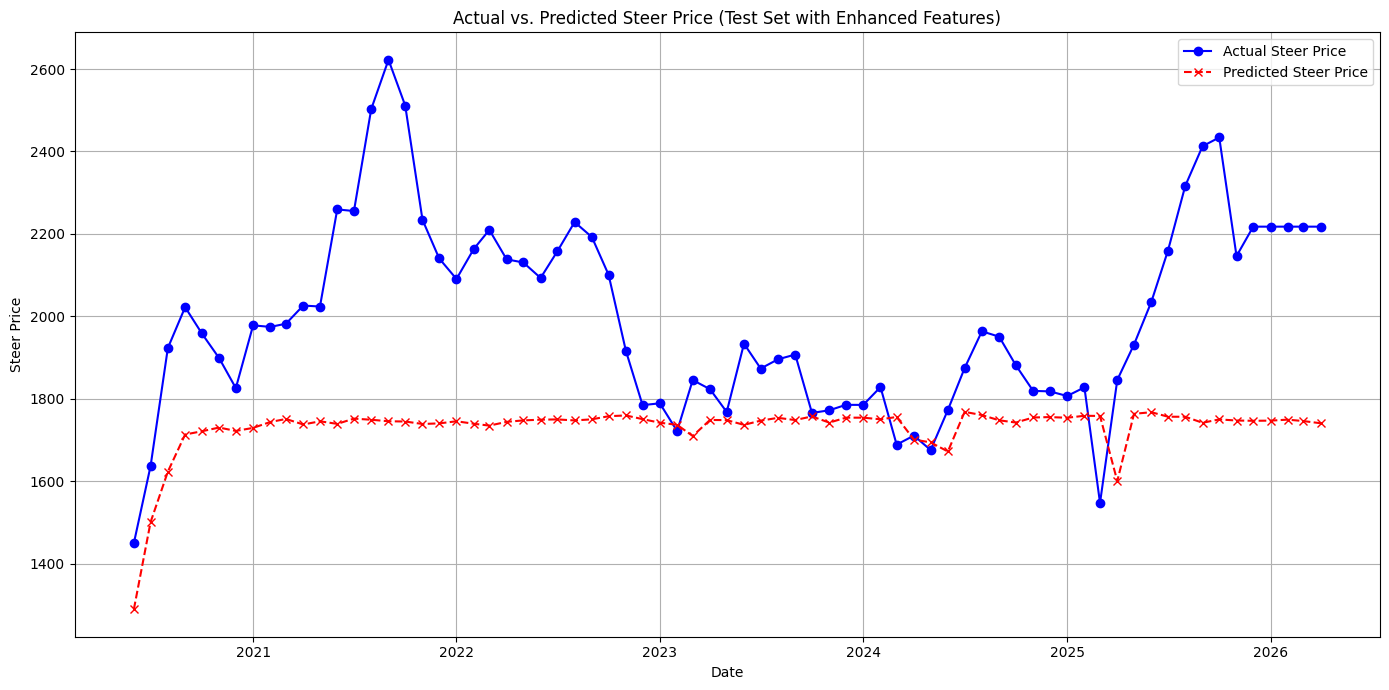

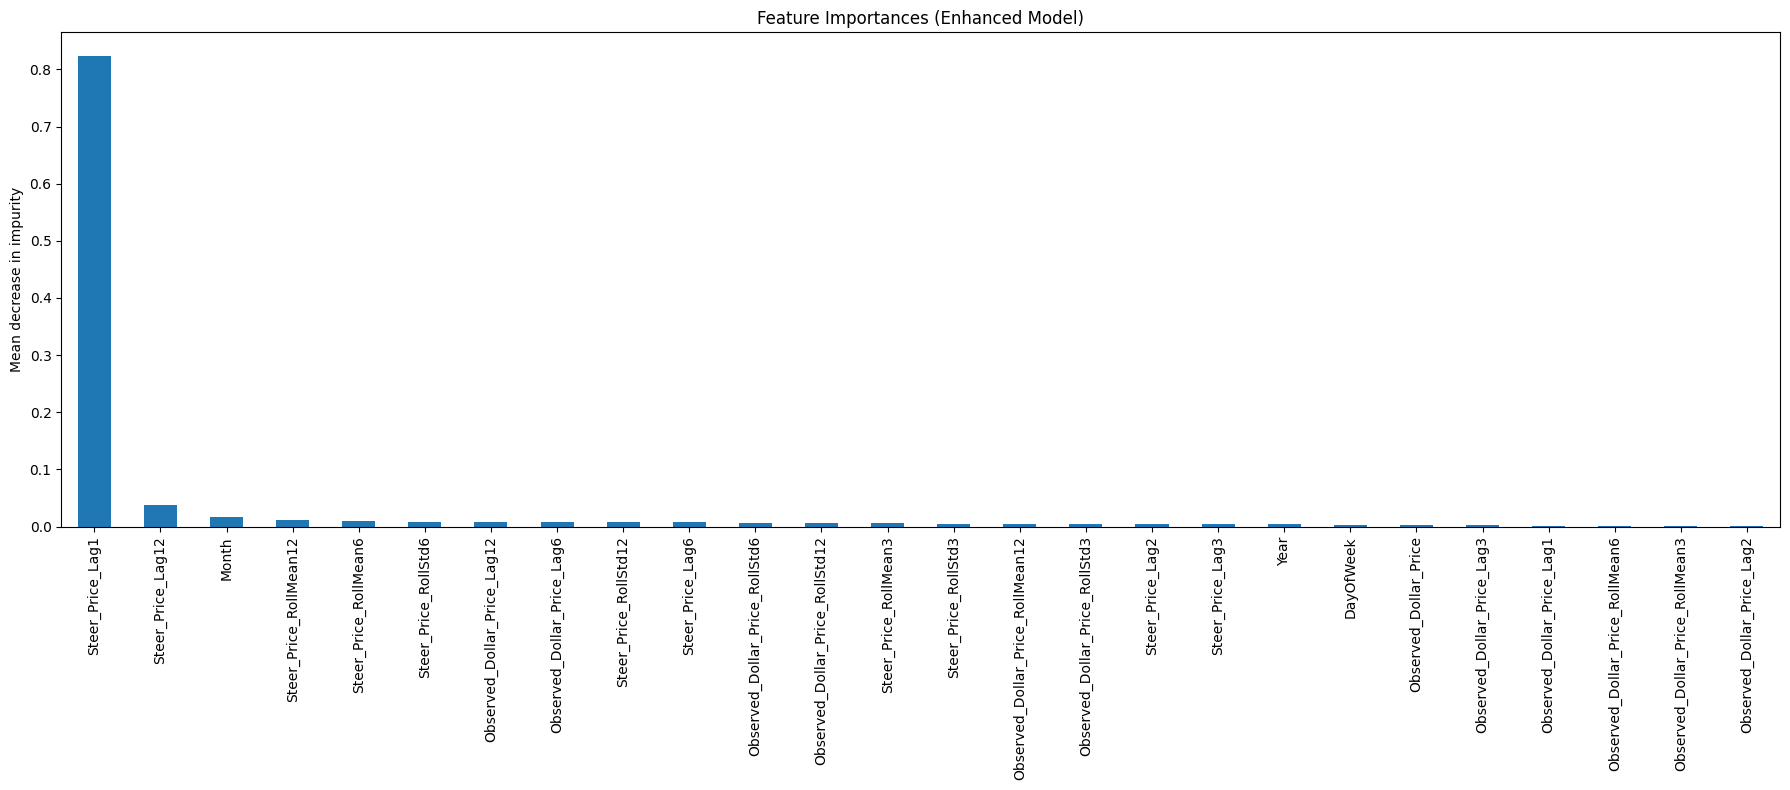

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd # Ensure pandas is imported for pd.Series

# Initialize the Random Forest Regressor model
model_enhanced = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1) # Using all available processors

print("Training the Random Forest Regressor model with enhanced features...")
# Train the model on the training data with enhanced features
model_enhanced.fit(X_train_enhanced, y_train_enhanced)
print("Model training with enhanced features complete.")

# Make predictions on the test set with enhanced features
y_pred_enhanced = model_enhanced.predict(X_test_enhanced)

# Evaluate the model
mse_enhanced = mean_squared_error(y_test_enhanced, y_pred_enhanced)
rmse_enhanced = np.sqrt(mse_enhanced)
r2_enhanced = r2_score(y_test_enhanced, y_pred_enhanced)

print(f"\nModel Evaluation on Test Set (Enhanced Features):")
print(f"Mean Squared Error (MSE): {mse_enhanced:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_enhanced:.2f}")
print(f"R-squared (R2): {r2_enhanced:.2f}")

# Plot actual vs. predicted values for the test set
plt.figure(figsize=(14, 7))
plt.plot(y_test_enhanced.index, y_test_enhanced, label='Actual Steer Price', color='blue', marker='o', linestyle='-')
plt.plot(y_test_enhanced.index, y_pred_enhanced, label='Predicted Steer Price', color='red', marker='x', linestyle='--')
plt.title('Actual vs. Predicted Steer Price (Test Set with Enhanced Features)')
plt.xlabel('Date')
plt.ylabel('Steer Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Optionally, visualize feature importances
importances_enhanced = model_enhanced.feature_importances_
feature_names_enhanced = X_train_enhanced.columns

forest_importances_enhanced = pd.Series(importances_enhanced, index=feature_names_enhanced)

fig, ax = plt.subplots(figsize=(18, 8)) # Increased figure size for more features
forest_importances_enhanced.sort_values(ascending=False).plot.bar(ax=ax)
ax.set_title("Feature Importances (Enhanced Model)")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()
plt.show()

## Hyperparameter Tuning with GridSearchCV

Given the current poor performance, let's try to optimize the Random Forest Regressor's hyperparameters using `GridSearchCV`. This method systematically works through multiple combinations of parameter values to find the best ones.

Starting GridSearchCV for hyperparameter tuning...
Fitting 3 folds for each of 324 candidates, totalling 972 fits
GridSearchCV complete.

Best parameters found: {'max_depth': 20, 'max_features': 0.8, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100}
Best R-squared score found during cross-validation: 0.58

Model Evaluation on Test Set (Enhanced Features with Tuned Hyperparameters):
Mean Squared Error (MSE): 125366.01
Root Mean Squared Error (RMSE): 354.07
R-squared (R2): -1.30


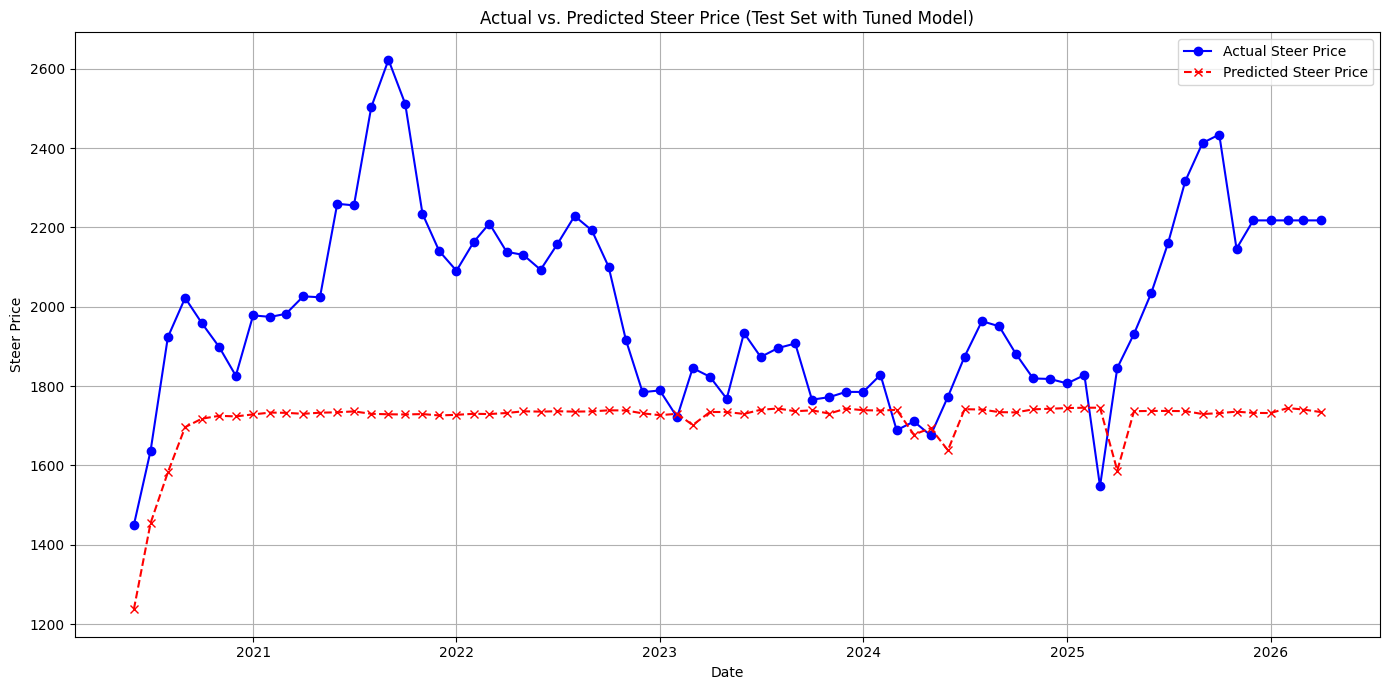

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

# Define the parameter grid to search
param_grid = {
    'n_estimators': [100, 200, 300], # Number of trees in the forest
    'max_features': ['sqrt', 'log2', 0.8], # Number of features to consider when looking for the best split
    'max_depth': [10, 20, 30, None], # Maximum number of levels in tree
    'min_samples_split': [2, 5, 10], # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4] # Minimum number of samples required to be at a leaf node
}

# Initialize the Random Forest Regressor
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

# Initialize GridSearchCV
# We will use the enhanced feature sets for tuning
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
                           cv=3, n_jobs=-1, verbose=2, scoring='r2')

print("Starting GridSearchCV for hyperparameter tuning...")
# Fit GridSearchCV to the enhanced training data
grid_search.fit(X_train_enhanced, y_train_enhanced)

print("GridSearchCV complete.")

# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"\nBest parameters found: {best_params}")
print(f"Best R-squared score found during cross-validation: {best_score:.2f}")

# Train a new model with the best parameters
best_rf_model = RandomForestRegressor(**best_params, random_state=42, n_jobs=-1)
best_rf_model.fit(X_train_enhanced, y_train_enhanced)

# Evaluate the best model on the test set
y_pred_tuned = best_rf_model.predict(X_test_enhanced)

mse_tuned = mean_squared_error(y_test_enhanced, y_pred_tuned)
rmse_tuned = np.sqrt(mse_tuned)
r2_tuned = r2_score(y_test_enhanced, y_pred_tuned)

print(f"\nModel Evaluation on Test Set (Enhanced Features with Tuned Hyperparameters):")
print(f"Mean Squared Error (MSE): {mse_tuned:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_tuned:.2f}")
print(f"R-squared (R2): {r2_tuned:.2f}")

# Plot actual vs. predicted values for the test set with tuned model
plt.figure(figsize=(14, 7))
plt.plot(y_test_enhanced.index, y_test_enhanced, label='Actual Steer Price', color='blue', marker='o', linestyle='-')
plt.plot(y_test_enhanced.index, y_pred_tuned, label='Predicted Steer Price', color='red', marker='x', linestyle='--')
plt.title('Actual vs. Predicted Steer Price (Test Set with Tuned Model)')
plt.xlabel('Date')
plt.ylabel('Steer Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# @title step_artifacts
num_fig = "5" # @param {type:"string"}
step = 'ModelOptimization'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "Summary"] {type:"string"}
# upload_plt_to_gcs(num_fig, step, fig)

## Load Vacas Price Data

Now, let's load the price data for 'vacas' (cows) from the `SeriesTiempoVacas.xls` file. This data might provide additional insights for predicting steer prices.

In [ ]:
vacas_file_path = '/content/drive/MyDrive/colab/SeriesTiempoVacas.xlsx'

# Check if the file exists
if os.path.exists(vacas_file_path):
    print(f"File found at: {vacas_file_path}. Attempting to load vacas data...")
    # Load the vacas price data Excel file
    vacas_df = pd.read_excel(vacas_file_path, header=0)

    # List of month columns (in Spanish)
    month_cols_vacas = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

    # Melt the DataFrame to transform month columns into rows
    vacas_df_melted = vacas_df.melt(
        id_vars=['Año'],
        value_vars=month_cols_vacas,
        var_name='Month_Abbr',
        value_name='Vacas_Price'
    )

    # Create a mapping for Spanish month abbreviations to numerical months
    month_map_vacas = {
        'Ene': 1, 'Feb': 2, 'Mar': 3, 'Abr': 4, 'May': 5, 'Jun': 6,
        'Jul': 7, 'Ago': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dic': 12
    }
    vacas_df_melted['Month'] = vacas_df_melted['Month_Abbr'].map(month_map_vacas)

    # Combine 'Año' and 'Month' to create a 'Date' column
    vacas_df_melted['Date'] = pd.to_datetime(
        vacas_df_melted['Año'].astype(str) + '-' + vacas_df_melted['Month'].astype(str) + '-01'
    )

    # Set 'Date' as the index and sort it
    vacas_df = vacas_df_melted.set_index('Date').sort_index()

    # Drop auxiliary columns
    vacas_df = vacas_df.drop(columns=['Año', 'Month_Abbr', 'Month'])

    # Display DataFrame info to verify data types and index
    print(vacas_df.info())

    # Display the head to see the effect of the conversion and renaming
    display(vacas_df.head())
else:
    print(f"Error: File not found at the specified path: {vacas_file_path}")
    print("Please ensure the file name and path are correct.")

File found at: /content/drive/MyDrive/colab/SeriesTiempoVacas.xlsx. Attempting to load vacas data...
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 252 entries, 2005-01-01 to 2025-12-01
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Vacas_Price  252 non-null    float64
dtypes: float64(1)
memory usage: 3.9 KB
None


,Vacas_Price
Date,
2005-01-01,728.53
2005-02-01,738.86
2005-03-01,740.89
2005-04-01,745.72
2005-05-01,778.11


In [ ]:
import pandas as pd

# Merge vacas_df with merged_df_filled on their Date indices
# This cell is re-generated here to ensure `merged_df_with_vacas` is defined before being used.
merged_df_with_vacas = pd.merge(merged_df_filled, vacas_df, left_index=True, right_index=True, how='left')

# Sort the DataFrame by date index (already sorted if indices are aligned, but good practice)
merged_df_with_vacas = merged_df_with_vacas.sort_index()

# Display DataFrame info to verify the new structure and non-null counts
print("\nMerged DataFrame with Vacas Prices Info:")
print(merged_df_with_vacas.info())

# Display the head of the new merged DataFrame
print("\nHead of Merged DataFrame with Vacas Prices:")
display(merged_df_with_vacas.head())

print("\nMissing values after merging with Vacas Prices:")
print(merged_df_with_vacas.isnull().sum())


Merged DataFrame with Vacas Prices Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 364 entries, 1996-01-01 to 2026-04-01
Data columns (total 10 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Observed_Dollar_Price            364 non-null    float64
 1   Steer_Price                      364 non-null    float64
 2   Steer_Price_Lag1                 363 non-null    float64
 3   Observed_Dollar_Price_Lag1       363 non-null    float64
 4   Steer_Price_RollMean3            361 non-null    float64
 5   Observed_Dollar_Price_RollMean3  361 non-null    float64
 6   Month                            364 non-null    int32  
 7   Year                             364 non-null    int32  
 8   DayOfWeek                        364 non-null    int32  
 9   Vacas_Price                      252 non-null    float64
dtypes: float64(7), int32(3)
memory usage: 27.0 KB
None

Head of Merged DataFrame with Vac

,Observed_Dollar_Price,Steer_Price,Steer_Price_Lag1,Observed_Dollar_Price_Lag1,Steer_Price_RollMean3,Observed_Dollar_Price_RollMean3,Month,Year,DayOfWeek,Vacas_Price
Date,,,,,,,,,,
1996-01-01,408.531818,1291.72,NaN,NaN,NaN,NaN,1,1996,0,NaN
1996-02-01,410.965714,1468.48,1291.72,408.531818,NaN,NaN,2,1996,3,NaN
1996-03-01,411.546667,1405.64,1468.48,410.965714,NaN,NaN,3,1996,4,NaN
1996-04-01,408.424762,1358.48,1405.64,411.546667,1388.613333,410.348066,4,1996,0,NaN
1996-05-01,406.230476,1318.20,1358.48,408.424762,1410.866667,410.312381,5,1996,2,NaN



Missing values after merging with Vacas Prices:
Observed_Dollar_Price                0
Steer_Price                          0
Steer_Price_Lag1                     1
Observed_Dollar_Price_Lag1           1
Steer_Price_RollMean3                3
Observed_Dollar_Price_RollMean3      3
Month                                0
Year                                 0
DayOfWeek                            0
Vacas_Price                        112
dtype: int64


### Debugging `SeriesTiempoVacas.xls` Loading Issue

Since we're still encountering a `KeyError` when trying to load `SeriesTiempoVacas.xls` with a specific header, it's possible the header row is not where we expect it to be, or the column names are slightly different.

Let's load the file *without* specifying a header and inspect the raw content. Please look at the output below and tell me:

1.  **Which row number (0-indexed) contains the actual column headers** (e.g., 'Año', 'Ene', 'Feb', etc.)?
2.  **Are the column names ('Año', 'Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic') exactly as expected, or are there any variations?**

In [ ]:
vacas_file_path = '/content/drive/MyDrive/colab/SeriesTiempoVacas.xlsx'

if os.path.exists(vacas_file_path):
    print(f"File found at: {vacas_file_path}. Loading raw vacas data for inspection...")
    # Load the Excel file without a header to inspect its raw structure
    raw_vacas_df = pd.read_excel(vacas_file_path, header=None)

    print("\nFirst 10 rows of the raw Excel content:")
    display(raw_vacas_df.head(10))
else:
    print(f"Error: File not found at the specified path: {vacas_file_path}")
    print("Please ensure the file name and path are correct.")

File found at: /content/drive/MyDrive/colab/SeriesTiempoVacas.xlsx. Loading raw vacas data for inspection...

First 10 rows of the raw Excel content:


,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,Año,Ene,Feb,Mar,Abr,May,Jun,Jul,Ago,Sep,Oct,Nov,Dic,Prom
1,2005,728.53,738.86,740.89,745.72,778.11,770.33,900.98,922.09,943.95,989.78,855,820.87,827.93
2,2006,758.48,803.94,727.83,740.3,677.34,699.91,767.09,857.72,909.71,906.87,853.57,750.38,787.76
3,2007,777.9,785.19,772.08,764.14,755.27,845.21,866.51,1003.19,1075.74,899.04,862.43,845.48,854.35
4,2008,706.24,714.05,694,756.27,783.85,936.99,1153.74,1374.28,1308.78,1063.11,915.84,759.25,930.53
5,2009,721.72,815.35,764.02,744.08,847.62,851.01,861.8,910.52,959.26,886.71,856.08,780.58,833.23
6,2010,846.49,933.72,940.41,881.2,938.75,982.32,1156.13,1108.84,1289.25,1210.69,1310.86,1150.55,1062.43
7,2011,1165.88,1147.73,1204.59,1177.41,1122.51,1169.97,1136.18,1246.6,1222.94,1296.94,1287.23,1096.9,1189.57
8,2012,1023.52,1188.19,1162.43,1111.2,1109.02,1073.79,1114.37,1120.06,1427.52,1172.77,1024.1,981.83,1125.73
9,2013,995.34,869.05,973.06,859.38,942.06,798.51,862.9,944.11,1138.65,973.69,938.03,834.47,927.44


In [ ]:
import os

# Define the directory path where the file is expected
directory_path = '/content/drive/MyDrive/colab/'

# Check if the directory exists
if os.path.isdir(directory_path):
    print(f"Contents of {directory_path}:")
    # List all files and directories in the specified path
    for item in os.listdir(directory_path):
        print(item)
else:
    print(f"Error: Directory not found at: {directory_path}")
    print("Please ensure the parent directories exist in your Google Drive.")

Contents of /content/drive/MyDrive/colab/:
Indicador.xls
SeriesTiempo_2026510.xls
SeriesTiempo_2026510 (1).xls
SeriesTiempo_2026510 (2).xls
SerieTiempoBovinoConsumo.xlsx
DolarHistorico.xlsm
SeriesTiempoVacas.xlsx


## Integrate Vacas Price Data

Now, let's merge the `vacas_df` with our `merged_df_filled` DataFrame. This will add the 'Vacas_Price' column to our dataset, which can be used for further feature engineering and modeling.

In [ ]:
# Merge vacas_df with merged_df_filled on their Date indices
merged_df_with_vacas = pd.merge(merged_df_filled, vacas_df, left_index=True, right_index=True, how='left')

# Sort the DataFrame by date index (already sorted if indices are aligned, but good practice)
merged_df_with_vacas = merged_df_with_vacas.sort_index()

# Display DataFrame info to verify the new structure and non-null counts
print("\nMerged DataFrame with Vacas Prices Info:")
print(merged_df_with_vacas.info())

# Display the head of the new merged DataFrame
print("\nHead of Merged DataFrame with Vacas Prices:")
display(merged_df_with_vacas.head())

print("\nMissing values after merging with Vacas Prices:")
print(merged_df_with_vacas.isnull().sum())


Merged DataFrame with Vacas Prices Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 364 entries, 1996-01-01 to 2026-04-01
Data columns (total 10 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Observed_Dollar_Price            364 non-null    float64
 1   Steer_Price                      364 non-null    float64
 2   Steer_Price_Lag1                 363 non-null    float64
 3   Observed_Dollar_Price_Lag1       363 non-null    float64
 4   Steer_Price_RollMean3            361 non-null    float64
 5   Observed_Dollar_Price_RollMean3  361 non-null    float64
 6   Month                            364 non-null    int32  
 7   Year                             364 non-null    int32  
 8   DayOfWeek                        364 non-null    int32  
 9   Vacas_Price                      252 non-null    float64
dtypes: float64(7), int32(3)
memory usage: 27.0 KB
None

Head of Merged DataFrame with Vac

,Observed_Dollar_Price,Steer_Price,Steer_Price_Lag1,Observed_Dollar_Price_Lag1,Steer_Price_RollMean3,Observed_Dollar_Price_RollMean3,Month,Year,DayOfWeek,Vacas_Price
Date,,,,,,,,,,
1996-01-01,408.531818,1291.72,NaN,NaN,NaN,NaN,1,1996,0,NaN
1996-02-01,410.965714,1468.48,1291.72,408.531818,NaN,NaN,2,1996,3,NaN
1996-03-01,411.546667,1405.64,1468.48,410.965714,NaN,NaN,3,1996,4,NaN
1996-04-01,408.424762,1358.48,1405.64,411.546667,1388.613333,410.348066,4,1996,0,NaN
1996-05-01,406.230476,1318.20,1358.48,408.424762,1410.866667,410.312381,5,1996,2,NaN



Missing values after merging with Vacas Prices:
Observed_Dollar_Price                0
Steer_Price                          0
Steer_Price_Lag1                     1
Observed_Dollar_Price_Lag1           1
Steer_Price_RollMean3                3
Observed_Dollar_Price_RollMean3      3
Month                                0
Year                                 0
DayOfWeek                            0
Vacas_Price                        112
dtype: int64


In [ ]:
# @title step_artifacts
num_fig = "4" # @param {type:"string"}
step = 'ModelOptimization'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "Summary"] {type:"string"}
# upload_plt_to_gcs(num_fig, step, fig)

## Create a New Dataset with Only Vacas Price Data

As requested, here is a new DataFrame containing solely the 'vacas' price data. This dataset is processed similarly to how it was done for integration, but kept separate.

In [ ]:
vacas_file_path = '/content/drive/MyDrive/colab/SeriesTiempoVacas.xlsx'

# Check if the file exists
if os.path.exists(vacas_file_path):
    print(f"File found at: {vacas_file_path}. Loading vacas data for a new dataset...")
    # Load the vacas price data Excel file
    vacas_only_df = pd.read_excel(vacas_file_path, header=0)

    # List of month columns (in Spanish)
    month_cols_vacas = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

    # Melt the DataFrame to transform month columns into rows
    vacas_only_df_melted = vacas_only_df.melt(
        id_vars=['Año'],
        value_vars=month_cols_vacas,
        var_name='Month_Abbr',
        value_name='Vacas_Price'
    )

    # Create a mapping for Spanish month abbreviations to numerical months
    month_map_vacas = {
        'Ene': 1, 'Feb': 2, 'Mar': 3, 'Abr': 4, 'May': 5, 'Jun': 6,
        'Jul': 7, 'Ago': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dic': 12
    }
    vacas_only_df_melted['Month'] = vacas_only_df_melted['Month_Abbr'].map(month_map_vacas)

    # Combine 'Año' and 'Month' to create a 'Date' column
    vacas_only_df_melted['Date'] = pd.to_datetime(
        vacas_only_df_melted['Año'].astype(str) + '-' + vacas_only_df_melted['Month'].astype(str) + '-01'
    )

    # Set 'Date' as the index and sort it
    vacas_only_df = vacas_only_df_melted.set_index('Date').sort_index()

    # Drop auxiliary columns
    vacas_only_df = vacas_only_df.drop(columns=['Año', 'Month_Abbr', 'Month'])

    # Display DataFrame info to verify data types and index
    print("\nDataFrame with only Vacas Prices Info:")
    print(vacas_only_df.info())

    # Display the head to see the effect of the conversion and renaming
    print("\nHead of DataFrame with only Vacas Prices:")
    display(vacas_only_df.head())
else:
    print(f"Error: File not found at the specified path: {vacas_file_path}")
    print("Please ensure the file name and path are correct.")

File found at: /content/drive/MyDrive/colab/SeriesTiempoVacas.xlsx. Loading vacas data for a new dataset...

DataFrame with only Vacas Prices Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 252 entries, 2005-01-01 to 2025-12-01
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Vacas_Price  252 non-null    float64
dtypes: float64(1)
memory usage: 3.9 KB
None

Head of DataFrame with only Vacas Prices:


,Vacas_Price
Date,
2005-01-01,728.53
2005-02-01,738.86
2005-03-01,740.89
2005-04-01,745.72
2005-05-01,778.11


In [ ]:
# Merge dolar_df and vacas_df on their Date indices
historicos_dolar_vacas_df = pd.merge(dolar_df, vacas_df, left_index=True, right_index=True, how='outer')

# Sort the DataFrame by date index
historicos_dolar_vacas_df = historicos_dolar_vacas_df.sort_index()

# Display DataFrame info to verify the merged structure and non-null counts
print("\nMerged DataFrame with Dolar and Vacas Prices Info:")
print(historicos_dolar_vacas_df.info())

# Display the head of the new merged DataFrame
print("\nHead of Merged DataFrame with Dolar and Vacas Prices:")
display(historicos_dolar_vacas_df.head())

print("\nMissing values after merging Dolar and Vacas Prices:")
print(historicos_dolar_vacas_df.isnull().sum())


Merged DataFrame with Dolar and Vacas Prices Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 360 entries, 1996-01-01 to 2025-12-01
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Observed_Dollar_Price  360 non-null    float64
 1   Vacas_Price            252 non-null    float64
dtypes: float64(2)
memory usage: 8.4 KB
None

Head of Merged DataFrame with Dolar and Vacas Prices:


,Observed_Dollar_Price,Vacas_Price
Date,,
1996-01-01,408.531818,NaN
1996-02-01,410.965714,NaN
1996-03-01,411.546667,NaN
1996-04-01,408.424762,NaN
1996-05-01,406.230476,NaN



Missing values after merging Dolar and Vacas Prices:
Observed_Dollar_Price      0
Vacas_Price              108
dtype: int64


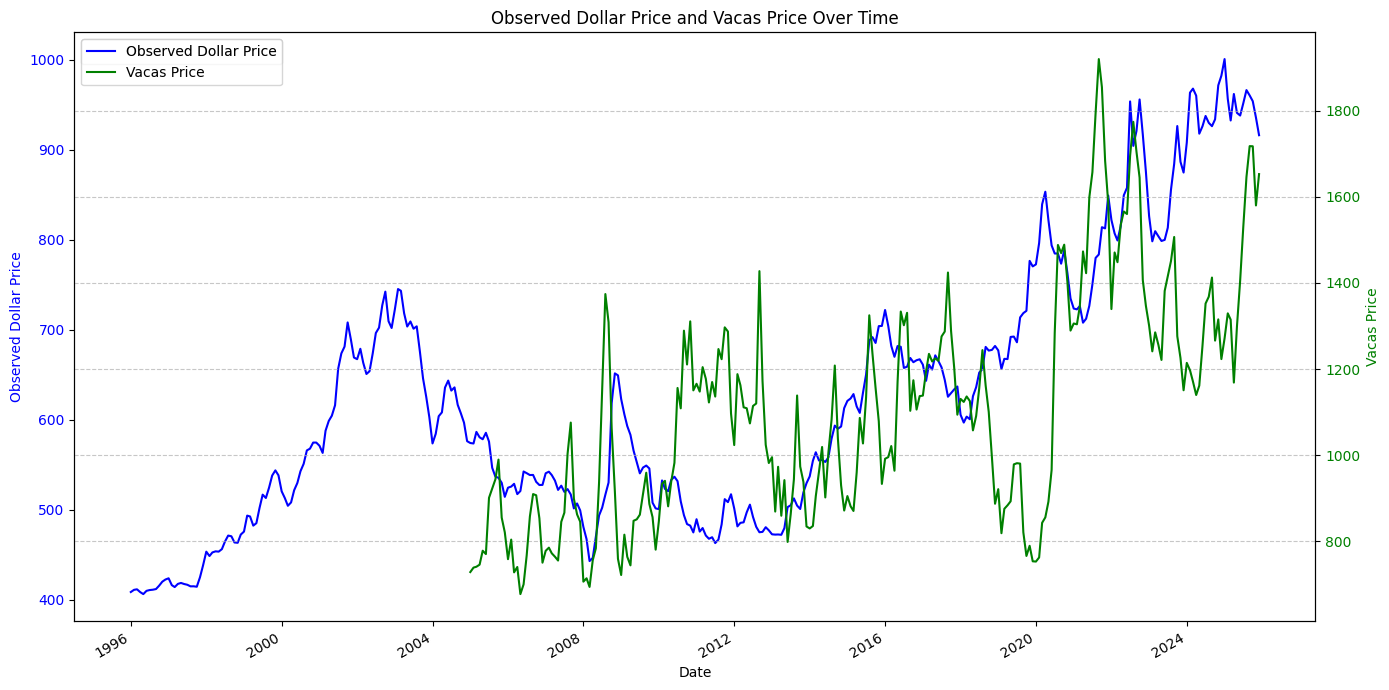

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure and a set of subplots
fig, ax1 = plt.subplots(figsize=(14, 7))

# Plot Observed_Dollar_Price on the first y-axis
sns.lineplot(x=historicos_dolar_vacas_df.index, y='Observed_Dollar_Price', data=historicos_dolar_vacas_df, ax=ax1, color='blue', label='Observed Dollar Price')
ax1.set_xlabel('Date')
ax1.set_ylabel('Observed Dollar Price', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Create a second y-axis for Vacas_Price
ax2 = ax1.twinx()
sns.lineplot(x=historicos_dolar_vacas_df.index, y='Vacas_Price', data=historicos_dolar_vacas_df, ax=ax2, color='green', label='Vacas Price')
ax2.set_ylabel('Vacas Price', color='green')
ax2.tick_params(axis='y', labelcolor='green')

# Add title and grid
plt.title('Observed Dollar Price and Vacas Price Over Time')
fig.autofmt_xdate() # Rotate x-axis labels for better readability
plt.grid(True, linestyle='--', alpha=0.7)

# Add legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

## Load Maize Price Data

Let's load and process the price data for 'Maiz' (corn) from the `SeriesTiempoMaiz.xlsx` file. This will create a separate dataset for maize prices.

In [ ]:
import os
import pandas as pd
import numpy as np

maiz_file_path = '/content/drive/MyDrive/colab/SeriesTiempoMaiz.xlsx'

# Check if the file exists
if os.path.exists(maiz_file_path):
    print(f"File found at: {maiz_file_path}. Attempting to load maize data...")
    # Load the maize price data Excel file
    maiz_df = pd.read_excel(maiz_file_path, header=0)

    # List of month columns (in Spanish)
    month_cols_maiz = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

    # Melt the DataFrame to transform month columns into rows
    maiz_df_melted = maiz_df.melt(
        id_vars=['Año'],
        value_vars=month_cols_maiz,
        var_name='Month_Abbr',
        value_name='Maiz_Price'
    )

    # Remove rows where 'Año' is not a valid year (e.g., footers like 'Fuente: ODEPA')
    maiz_df_melted = maiz_df_melted[pd.to_numeric(maiz_df_melted['Año'], errors='coerce').notna()]
    maiz_df_melted['Año'] = maiz_df_melted['Año'].astype(int) # Convert 'Año' to int after filtering

    # Create a mapping for Spanish month abbreviations to numerical months
    month_map_maiz = {
        'Ene': 1, 'Feb': 2, 'Mar': 3, 'Abr': 4, 'May': 5, 'Jun': 6,
        'Jul': 7, 'Ago': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dic': 12
    }
    maiz_df_melted['Month'] = maiz_df_melted['Month_Abbr'].map(month_map_maiz)

    # Combine 'Año' and 'Month' to create a 'Date' column
    maiz_df_melted['Date'] = pd.to_datetime(
        maiz_df_melted['Año'].astype(str) + '-' + maiz_df_melted['Month'].astype(str) + '-01'
    )

    # Set 'Date' as the index and sort it
    maiz_df = maiz_df_melted.set_index('Date').sort_index()

    # Drop auxiliary columns
    maiz_df = maiz_df.drop(columns=['Año', 'Month_Abbr', 'Month'])

    # Display DataFrame info to verify data types and index
    print(maiz_df.info())

    # Display the head to see the effect of the conversion and renaming
    display(maiz_df.head())
else:
    print(f"Error: File not found at the specified path: {maiz_file_path}")
    print("Please ensure the file name and path are correct.")

File found at: /content/drive/MyDrive/colab/SeriesTiempoMaiz.xlsx. Attempting to load maize data...
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 252 entries, 2005-01-01 to 2025-12-01
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Maiz_Price  252 non-null    float64
dtypes: float64(1)
memory usage: 3.9 KB
None


,Maiz_Price
Date,
2005-01-01,233.28
2005-02-01,230.65
2005-03-01,246.48
2005-04-01,232.48
2005-05-01,227.58


## Integrate Maize Price Data

Now, let's merge the `maiz_df` with our `merged_df_with_vacas` DataFrame. This will add the 'Maiz_Price' column to our dataset, which can be used for further feature engineering and modeling.

In [ ]:
# Merge maiz_df with merged_df_with_vacas on their Date indices
merged_df_with_vacas_maiz = pd.merge(merged_df_with_vacas, maiz_df, left_index=True, right_index=True, how='left')

# Sort the DataFrame by date index (already sorted if indices are aligned, but good practice)
merged_df_with_vacas_maiz = merged_df_with_vacas_maiz.sort_index()

# Display DataFrame info to verify the new structure and non-null counts
print("\nMerged DataFrame with Vacas and Maiz Prices Info:")
print(merged_df_with_vacas_maiz.info())

# Display the head of the new merged DataFrame
print("\nHead of Merged DataFrame with Vacas and Maiz Prices:")
display(merged_df_with_vacas_maiz.head())

print("\nMissing values after merging with Vacas and Maiz Prices:")
print(merged_df_with_vacas_maiz.isnull().sum())


Merged DataFrame with Vacas and Maiz Prices Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 364 entries, 1996-01-01 to 2026-04-01
Data columns (total 11 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Observed_Dollar_Price            364 non-null    float64
 1   Steer_Price                      364 non-null    float64
 2   Steer_Price_Lag1                 363 non-null    float64
 3   Observed_Dollar_Price_Lag1       363 non-null    float64
 4   Steer_Price_RollMean3            361 non-null    float64
 5   Observed_Dollar_Price_RollMean3  361 non-null    float64
 6   Month                            364 non-null    int32  
 7   Year                             364 non-null    int32  
 8   DayOfWeek                        364 non-null    int32  
 9   Vacas_Price                      252 non-null    float64
 10  Maiz_Price                       252 non-null    float64
dtypes: float64(8),

,Observed_Dollar_Price,Steer_Price,Steer_Price_Lag1,Observed_Dollar_Price_Lag1,Steer_Price_RollMean3,Observed_Dollar_Price_RollMean3,Month,Year,DayOfWeek,Vacas_Price,Maiz_Price
Date,,,,,,,,,,,
1996-01-01,408.531818,1291.72,NaN,NaN,NaN,NaN,1,1996,0,NaN,NaN
1996-02-01,410.965714,1468.48,1291.72,408.531818,NaN,NaN,2,1996,3,NaN,NaN
1996-03-01,411.546667,1405.64,1468.48,410.965714,NaN,NaN,3,1996,4,NaN,NaN
1996-04-01,408.424762,1358.48,1405.64,411.546667,1388.613333,410.348066,4,1996,0,NaN,NaN
1996-05-01,406.230476,1318.20,1358.48,408.424762,1410.866667,410.312381,5,1996,2,NaN,NaN



Missing values after merging with Vacas and Maiz Prices:
Observed_Dollar_Price                0
Steer_Price                          0
Steer_Price_Lag1                     1
Observed_Dollar_Price_Lag1           1
Steer_Price_RollMean3                3
Observed_Dollar_Price_RollMean3      3
Month                                0
Year                                 0
DayOfWeek                            0
Vacas_Price                        112
Maiz_Price                         112
dtype: int64


### Adjusting Dollar Price to Real Values (CPI April 2026 Base)

To ensure all monetary values are in consistent 'real' terms, we will now adjust the `Observed_Dollar_Price` using the CPI index. We'll set April 2026 as our base period, meaning the 'Real_Observed_Dollar_Price' will reflect its purchasing power relative to April 2026.

In [ ]:
import pandas as pd
import os

# --- Re-create cpi_df with CPI_Index for merging ---
cpi_file_path = '/content/drive/MyDrive/colab/Indicador.xls'

if os.path.exists(cpi_file_path):
    print(f"File found at: {cpi_file_path}. Attempting to re-load CPI data...")
    cpi_df_for_merge = pd.read_excel(cpi_file_path, skiprows=3)
else:
    print(f"Error: CPI file not found at: {cpi_file_path}")
    raise FileNotFoundError(f"CPI file not found: {cpi_file_path}")

cpi_df_for_merge['Mes'] = pd.to_datetime(cpi_df_for_merge['Mes'])
cpi_df_for_merge = cpi_df_for_merge.rename(columns={'Mes': 'Date', 'Valor': 'Monthly_Percentage_Change'})
cpi_df_for_merge = cpi_df_for_merge.set_index('Date')
cpi_df_for_merge['Factor'] = 1 + (cpi_df_for_merge['Monthly_Percentage_Change'] / 100)

base_cpi_value = 100.0
cpi_df_for_merge['CPI_Index'] = cpi_df_for_merge['Factor'].cumprod() * base_cpi_value / cpi_df_for_merge.loc[cpi_df_for_merge.index.min(), 'Factor']
cpi_df_for_merge = cpi_df_for_merge.drop(columns=['Factor', 'Monthly_Percentage_Change'])
print("CPI data re-prepared successfully.")

# --- Ensure merged_df_with_vacas_maiz is available by re-creating it ---

# Re-load dolar_df
dolar_file_path = '/content/drive/MyDrive/colab/DolarHistorico.xlsm'
if os.path.exists(dolar_file_path):
    dolar_df = pd.read_excel(dolar_file_path, header=0)
    dolar_df['Periodo'] = pd.to_datetime(dolar_df['Periodo'])
    dolar_df = dolar_df.rename(columns={'Periodo': 'Date', '1. Dólar observado': 'Observed_Dollar_Price'})
    dolar_df = dolar_df.set_index('Date')
else:
    raise FileNotFoundError(f"Dolar file not found: {dolar_file_path}")

# Re-load livestock_df
livestock_file_path = '/content/drive/MyDrive/colab/SerieTiempoBovinoConsumo.xlsx'
if os.path.exists(livestock_file_path):
    livestock_df = pd.read_excel(livestock_file_path, header=0)
    if 'Unnamed: 0' in livestock_df.columns:
        livestock_df = livestock_df.drop(columns=['Unnamed: 0'])
    month_cols = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
    livestock_df_melted = livestock_df.melt(id_vars=['Año'], value_vars=month_cols, var_name='Month_Abbr', value_name='Steer_Price')
    month_map = {'Ene': 1, 'Feb': 2, 'Mar': 3, 'Abr': 4, 'May': 5, 'Jun': 6, 'Jul': 7, 'Ago': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dic': 12}
    livestock_df_melted['Month'] = livestock_df_melted['Month_Abbr'].map(month_map)
    livestock_df_melted['Date'] = pd.to_datetime(livestock_df_melted['Año'].astype(str) + '-' + livestock_df_melted['Month'].astype(str) + '-01')
    livestock_df = livestock_df_melted.set_index('Date').sort_index()
    livestock_df = livestock_df.drop(columns=['Año', 'Month_Abbr', 'Month'])
else:
    raise FileNotFoundError(f"Livestock file not found: {livestock_file_path}")

# Re-load vacas_df
vacas_file_path = '/content/drive/MyDrive/colab/SeriesTiempoVacas.xlsx'
if os.path.exists(vacas_file_path):
    vacas_df = pd.read_excel(vacas_file_path, header=0)
    month_cols_vacas = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
    vacas_df_melted = vacas_df.melt(id_vars=['Año'], value_vars=month_cols_vacas, var_name='Month_Abbr', value_name='Vacas_Price')
    month_map_vacas = {'Ene': 1, 'Feb': 2, 'Mar': 3, 'Abr': 4, 'May': 5, 'Jun': 6, 'Jul': 7, 'Ago': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dic': 12}
    vacas_df_melted['Month'] = vacas_df_melted['Month_Abbr'].map(month_map_vacas)
    vacas_df_melted['Date'] = pd.to_datetime(vacas_df_melted['Año'].astype(str) + '-' + vacas_df_melted['Month'].astype(str) + '-01')
    vacas_df = vacas_df_melted.set_index('Date').sort_index()
    vacas_df = vacas_df.drop(columns=['Año', 'Month_Abbr', 'Month'])
else:
    raise FileNotFoundError(f"Vacas file not found: {vacas_file_path}")

# Re-load maiz_df
maiz_file_path = '/content/drive/MyDrive/colab/SeriesTiempoMaiz.xlsx'
if os.path.exists(maiz_file_path):
    maiz_df = pd.read_excel(maiz_file_path, header=0)
    month_cols_maiz = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
    maiz_df_melted = maiz_df.melt(id_vars=['Año'], value_vars=month_cols_maiz, var_name='Month_Abbr', value_name='Maiz_Price')
    maiz_df_melted = maiz_df_melted[pd.to_numeric(maiz_df_melted['Año'], errors='coerce').notna()]
    maiz_df_melted['Año'] = maiz_df_melted['Año'].astype(int)
    month_map_maiz = {'Ene': 1, 'Feb': 2, 'Mar': 3, 'Abr': 4, 'May': 5, 'Jun': 6, 'Jul': 7, 'Ago': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dic': 12}
    maiz_df_melted['Month'] = maiz_df_melted['Month_Abbr'].map(month_map_maiz)
    maiz_df_melted['Date'] = pd.to_datetime(maiz_df_melted['Año'].astype(str) + '-' + maiz_df_melted['Month'].astype(str) + '-01')
    maiz_df = maiz_df_melted.set_index('Date').sort_index()
    maiz_df = maiz_df.drop(columns=['Año', 'Month_Abbr', 'Month'])
else:
    raise FileNotFoundError(f"Maiz file not found: {maiz_file_path}")

# Re-merge all dataframes to reconstruct merged_df_with_vacas_maiz
merged_df_base = pd.merge(dolar_df, livestock_df, on='Date', how='outer')
merged_df_base = pd.merge(merged_df_base, vacas_df, on='Date', how='outer')
merged_df_with_vacas_maiz = pd.merge(merged_df_base, maiz_df, on='Date', how='outer')
merged_df_with_vacas_maiz = merged_df_with_vacas_maiz.sort_index()
merged_df_with_vacas_maiz = merged_df_with_vacas_maiz.ffill() # Apply ffill for missing values after initial merge

print("All required dataframes re-prepared and merged to form merged_df_with_vacas_maiz.")

# --- Merge CPI_Index into the main DataFrame ---
final_merged_df = pd.merge(merged_df_with_vacas_maiz, cpi_df_for_merge['CPI_Index'], left_index=True, right_index=True, how='left')

# --- Adjust Observed_Dollar_Price to Real Values ---
# Get the CPI for April 2026 directly from cpi_df_for_merge
try:
    cpi_april_2026 = cpi_df_for_merge.loc[pd.to_datetime('2026-04-01'), 'CPI_Index']
    print(f"CPI for April 2026: {cpi_april_2026:.2f}")
except KeyError:
    print("Warning: CPI for April 2026 not found in the CPI data. Using the last available CPI as base.")
    cpi_april_2026 = cpi_df_for_merge['CPI_Index'].iloc[-1]

final_merged_df['Real_Observed_Dollar_Price'] = final_merged_df['Observed_Dollar_Price'] * (cpi_april_2026 / final_merged_df['CPI_Index'])

print("\nDataFrame with Real_Observed_Dollar_Price:")
print(final_merged_df.info())
display(final_merged_df.head())

print("\nFirst few rows of the DataFrame showing nominal and real dollar prices:")
display(final_merged_df[['Observed_Dollar_Price', 'CPI_Index', 'Real_Observed_Dollar_Price']].head())

File found at: /content/drive/MyDrive/colab/Indicador.xls. Attempting to re-load CPI data...
CPI data re-prepared successfully.
All required dataframes re-prepared and merged to form merged_df_with_vacas_maiz.
CPI for April 2026: 324.51

DataFrame with Real_Observed_Dollar_Price:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 360 entries, 1996-01-01 to 2025-12-01
Data columns (total 6 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Observed_Dollar_Price       360 non-null    float64
 1   Steer_Price                 360 non-null    float64
 2   Vacas_Price                 252 non-null    float64
 3   Maiz_Price                  252 non-null    float64
 4   CPI_Index                   360 non-null    float64
 5   Real_Observed_Dollar_Price  360 non-null    float64
dtypes: float64(6)
memory usage: 19.7 KB
None


,Observed_Dollar_Price,Steer_Price,Vacas_Price,Maiz_Price,CPI_Index,Real_Observed_Dollar_Price
Date,,,,,,
1996-01-01,408.531818,1291.72,NaN,NaN,100.000000,1325.731003
1996-02-01,410.965714,1468.48,NaN,NaN,100.500000,1326.994294
1996-03-01,411.546667,1405.64,NaN,NaN,101.203500,1319.632740
1996-04-01,408.424762,1358.48,NaN,NaN,102.215535,1296.655732
1996-05-01,406.230476,1318.20,NaN,NaN,103.033259,1279.453744



First few rows of the DataFrame showing nominal and real dollar prices:


,Observed_Dollar_Price,CPI_Index,Real_Observed_Dollar_Price
Date,,,
1996-01-01,408.531818,100.000000,1325.731003
1996-02-01,410.965714,100.500000,1326.994294
1996-03-01,411.546667,101.203500,1319.632740
1996-04-01,408.424762,102.215535,1296.655732
1996-05-01,406.230476,103.033259,1279.453744


### Removing Nominal Observed Dollar Price

As requested, I am removing the `Observed_Dollar_Price` column from `final_merged_df` as we are now using the `Real_Observed_Dollar_Price` for inflation adjustment. The `Steer_Price` column will remain, as it is our target variable for prediction.

In [ ]:
# Remove 'Observed_Dollar_Price' from final_merged_df
if 'Observed_Dollar_Price' in final_merged_df.columns:
    final_merged_df = final_merged_df.drop(columns=['Observed_Dollar_Price'])
    print("Successfully removed 'Observed_Dollar_Price' from final_merged_df.")
else:
    print("'Observed_Dollar_Price' not found in final_merged_df. No action needed.")

print("\nUpdated final_merged_df info:")
print(final_merged_df.info())
display(final_merged_df.head())

Successfully removed 'Observed_Dollar_Price' from final_merged_df.

Updated final_merged_df info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 360 entries, 1996-01-01 to 2025-12-01
Data columns (total 5 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Steer_Price                 360 non-null    float64
 1   Vacas_Price                 252 non-null    float64
 2   Maiz_Price                  252 non-null    float64
 3   CPI_Index                   360 non-null    float64
 4   Real_Observed_Dollar_Price  360 non-null    float64
dtypes: float64(5)
memory usage: 16.9 KB
None


,Steer_Price,Vacas_Price,Maiz_Price,CPI_Index,Real_Observed_Dollar_Price
Date,,,,,
1996-01-01,1291.72,NaN,NaN,100.000000,1325.731003
1996-02-01,1468.48,NaN,NaN,100.500000,1326.994294
1996-03-01,1405.64,NaN,NaN,101.203500,1319.632740
1996-04-01,1358.48,NaN,NaN,102.215535,1296.655732
1996-05-01,1318.20,NaN,NaN,103.033259,1279.453744


In [ ]:
# Remove 'Steer_Price' from final_merged_df as Vacas_Price is now the target
if 'Steer_Price' in final_merged_df.columns:
    final_merged_df = final_merged_df.drop(columns=['Steer_Price'])
    print("Successfully removed 'Steer_Price' from final_merged_df.")
else:
    print("'Steer_Price' not found in final_merged_df. No action needed.")

print("\nUpdated final_merged_df info:")
print(final_merged_df.info())
display(final_merged_df.head())

Successfully removed 'Steer_Price' from final_merged_df.

Updated final_merged_df info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 360 entries, 1996-01-01 to 2025-12-01
Data columns (total 4 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Vacas_Price                 252 non-null    float64
 1   Maiz_Price                  252 non-null    float64
 2   CPI_Index                   360 non-null    float64
 3   Real_Observed_Dollar_Price  360 non-null    float64
dtypes: float64(4)
memory usage: 14.1 KB
None


,Vacas_Price,Maiz_Price,CPI_Index,Real_Observed_Dollar_Price
Date,,,,
1996-01-01,NaN,NaN,100.000000,1325.731003
1996-02-01,NaN,NaN,100.500000,1326.994294
1996-03-01,NaN,NaN,101.203500,1319.632740
1996-04-01,NaN,NaN,102.215535,1296.655732
1996-05-01,NaN,NaN,103.033259,1279.453744


## Enhanced Feature Engineering (Re-aligned for Vacas Price Target)

I am now updating the enhanced feature engineering process. Features will be generated for `Real_Observed_Dollar_Price`, `Vacas_Price` (which is now the target, so its features will be based on lagged values of itself), and `Maiz_Price`. The original `Observed_Dollar_Price` and `Steer_Price` columns are excluded from feature generation.

In [ ]:
# Create a copy of the final_merged_df for enhanced feature engineering
merged_df_enhanced = final_merged_df.copy()

# --- Lag Features ---
lags = [1, 2, 3, 6, 12] # Lags for 1, 2, 3, 6, and 12 months

# Generate lag features for the new set of relevant prices
for lag in lags:
    merged_df_enhanced[f'Real_Observed_Dollar_Price_Lag{lag}'] = merged_df_enhanced['Real_Observed_Dollar_Price'].shift(lag)
    merged_df_enhanced[f'Vacas_Price_Lag{lag}'] = merged_df_enhanced['Vacas_Price'].shift(lag)
    merged_df_enhanced[f'Maiz_Price_Lag{lag}'] = merged_df_enhanced['Maiz_Price'].shift(lag)

# --- Rolling Statistics ---
windows = [3, 6, 12] # Rolling windows for 3, 6, and 12 months

# Generate rolling statistics for the new set of relevant prices
for window in windows:
    # Rolling Mean
    merged_df_enhanced[f'Real_Observed_Dollar_Price_RollMean{window}'] = merged_df_enhanced['Real_Observed_Dollar_Price'].rolling(window=window).mean().shift(1)
    merged_df_enhanced[f'Vacas_Price_RollMean{window}'] = merged_df_enhanced['Vacas_Price'].rolling(window=window).mean().shift(1)
    merged_df_enhanced[f'Maiz_Price_RollMean{window}'] = merged_df_enhanced['Maiz_Price'].rolling(window=window).mean().shift(1)
    # Rolling Standard Deviation
    merged_df_enhanced[f'Real_Observed_Dollar_Price_RollStd{window}'] = merged_df_enhanced['Real_Observed_Dollar_Price'].rolling(window=window).std().shift(1)
    merged_df_enhanced[f'Vacas_Price_RollStd{window}'] = merged_df_enhanced['Vacas_Price'].rolling(window=window).std().shift(1)
    merged_df_enhanced[f'Maiz_Price_RollStd{window}'] = merged_df_enhanced['Maiz_Price'].rolling(window=window).std().shift(1)

# --- Time-based Features ---
merged_df_enhanced['Month'] = merged_df_enhanced.index.month
merged_df_enhanced['Year'] = merged_df_enhanced.index.year
merged_df_enhanced['DayOfWeek'] = merged_df_enhanced.index.dayofweek

# Drop original columns that are now target or replaced by features. Keep 'Vacas_Price' for now as it's the target.
# 'Observed_Dollar_Price' was already removed. 'Steer_Price' was also removed.
merged_df_enhanced_temp = merged_df_enhanced.drop(columns=['Real_Observed_Dollar_Price', 'Maiz_Price', 'CPI_Index'])

# Drop rows with NaN values resulting from lag/rolling features
merged_df_features_enhanced = merged_df_enhanced_temp.dropna()

print("DataFrame with enhanced features (for Vacas Price target) and no NaNs:")
print(merged_df_features_enhanced.info())
display(merged_df_features_enhanced.head())

DataFrame with enhanced features (for Vacas Price target) and no NaNs:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 240 entries, 2006-01-01 to 2025-12-01
Data columns (total 37 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Vacas_Price                            240 non-null    float64
 1   Real_Observed_Dollar_Price_Lag1        240 non-null    float64
 2   Vacas_Price_Lag1                       240 non-null    float64
 3   Maiz_Price_Lag1                        240 non-null    float64
 4   Real_Observed_Dollar_Price_Lag2        240 non-null    float64
 5   Vacas_Price_Lag2                       240 non-null    float64
 6   Maiz_Price_Lag2                        240 non-null    float64
 7   Real_Observed_Dollar_Price_Lag3        240 non-null    float64
 8   Vacas_Price_Lag3                       240 non-null    float64
 9   Maiz_Price_Lag3                        240 non-null 

,Vacas_Price,Real_Observed_Dollar_Price_Lag1,Vacas_Price_Lag1,Maiz_Price_Lag1,Real_Observed_Dollar_Price_Lag2,Vacas_Price_Lag2,Maiz_Price_Lag2,Real_Observed_Dollar_Price_Lag3,Vacas_Price_Lag3,Maiz_Price_Lag3,...,Maiz_Price_RollStd6,Real_Observed_Dollar_Price_RollMean12,Vacas_Price_RollMean12,Maiz_Price_RollMean12,Real_Observed_Dollar_Price_RollStd12,Vacas_Price_RollStd12,Maiz_Price_RollStd12,Month,Year,DayOfWeek
Date,,,,,,,,,,,,,,,,,,,,,
2006-01-01,758.48,1170.589714,820.87,237.89,1202.363820,855.00,224.13,1212.676006,989.78,238.54,...,8.860776,1296.100076,827.925833,235.216667,76.921909,91.745281,7.500697,1,2006,6
2006-02-01,803.94,1192.488673,758.48,239.76,1170.589714,820.87,237.89,1202.363820,855.00,224.13,...,5.769813,1282.159904,830.421667,235.756667,79.450505,89.166649,7.581419,2,2006,2
2006-03-01,727.83,1196.476496,803.94,249.03,1192.488673,758.48,239.76,1170.589714,820.87,237.89,...,8.221176,1268.544426,835.845000,237.288333,78.922073,84.971864,8.280362,3,2006,2
2006-04-01,740.30,1196.277730,727.83,244.47,1196.476496,803.94,249.03,1192.488673,758.48,239.76,...,8.410168,1253.055083,834.756667,237.120833,72.584043,86.370748,8.095797,4,2006,5
2006-05-01,677.34,1163.405431,740.30,249.98,1196.277730,727.83,244.47,1196.476496,803.94,249.03,...,9.517117,1237.026833,834.305000,238.579167,68.994056,86.891287,8.734786,5,2006,0


### Data Split with Enhanced Features (Updated for Vacas Price Target)

I am re-splitting the data into training and testing sets, now targeting `Vacas_Price`. This step ensures `X_train_enhanced` and `y_train_enhanced` are properly defined for model training with the new target.

In [ ]:
from sklearn.model_selection import train_test_split

# Define the target variable (what we want to predict) as Vacas_Price
y_enhanced = merged_df_features_enhanced['Vacas_Price']

# Define the features (variables used for prediction), dropping Vacas_Price from X
X_enhanced = merged_df_features_enhanced.drop(columns=['Vacas_Price'])

# Determine the split point (e.g., 80% for training, 20% for testing)
split_point_enhanced = int(len(X_enhanced) * 0.8)

X_train_enhanced, X_test_enhanced = X_enhanced.iloc[:split_point_enhanced], X_enhanced.iloc[split_point_enhanced:]
y_train_enhanced, y_test_enhanced = y_enhanced.iloc[:split_point_enhanced], y_enhanced.iloc[split_point_enhanced:]

print(f"Training set size (enhanced features for Vacas Price): {len(X_train_enhanced)} samples")
print(f"Testing set size (enhanced features for Vacas Price): {len(X_test_enhanced)} samples")

Training set size (enhanced features for Vacas Price): 192 samples
Testing set size (enhanced features for Vacas Price): 48 samples


### Hyperparameter Tuning with GridSearchCV (Re-run for Vacas Price Target)

Next, I'm re-running the hyperparameter tuning to ensure `best_rf_model` is trained and available for predictions on `Vacas_Price`. This uses the `X_train_enhanced` and `y_train_enhanced` created in the previous step.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Define the parameter grid to search
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_features': ['sqrt', 'log2', 0.8],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize the Random Forest Regressor
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
                           cv=3, n_jobs=-1, verbose=0, scoring='r2') # verbose=0 to reduce output

print("Starting GridSearchCV for hyperparameter tuning...")
grid_search.fit(X_train_enhanced, y_train_enhanced)
print("GridSearchCV complete.")

best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"\nBest parameters found: {best_params}")
print(f"Best R-squared score found during cross-validation: {best_score:.2f}")

# Train a new model with the best parameters
best_rf_model = RandomForestRegressor(**best_params, random_state=42, n_jobs=-1)
best_rf_model.fit(X_train_enhanced, y_train_enhanced)

# Evaluate the best model on the test set
y_pred_tuned = best_rf_model.predict(X_test_enhanced)

mse_tuned = mean_squared_error(y_test_enhanced, y_pred_tuned)
rmse_tuned = np.sqrt(mse_tuned)
r2_tuned = r2_score(y_test_enhanced, y_pred_tuned)

print(f"\nModel Evaluation on Test Set (Enhanced Features with Tuned Hyperparameters for Vacas Price):")
print(f"Mean Squared Error (MSE): {mse_tuned:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_tuned:.2f}")
print(f"R-squared (R2): {r2_tuned:.2f}")

Starting GridSearchCV for hyperparameter tuning...
GridSearchCV complete.

Best parameters found: {'max_depth': 20, 'max_features': 0.8, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}
Best R-squared score found during cross-validation: 0.53

Model Evaluation on Test Set (Enhanced Features with Tuned Hyperparameters for Vacas Price):
Mean Squared Error (MSE): 25125.47
Root Mean Squared Error (RMSE): 158.51
R-squared (R2): 0.19


/tmp/ipykernel_11078/438738214.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=forest_importances.index, y=forest_importances.values, ax=ax, palette='viridis')


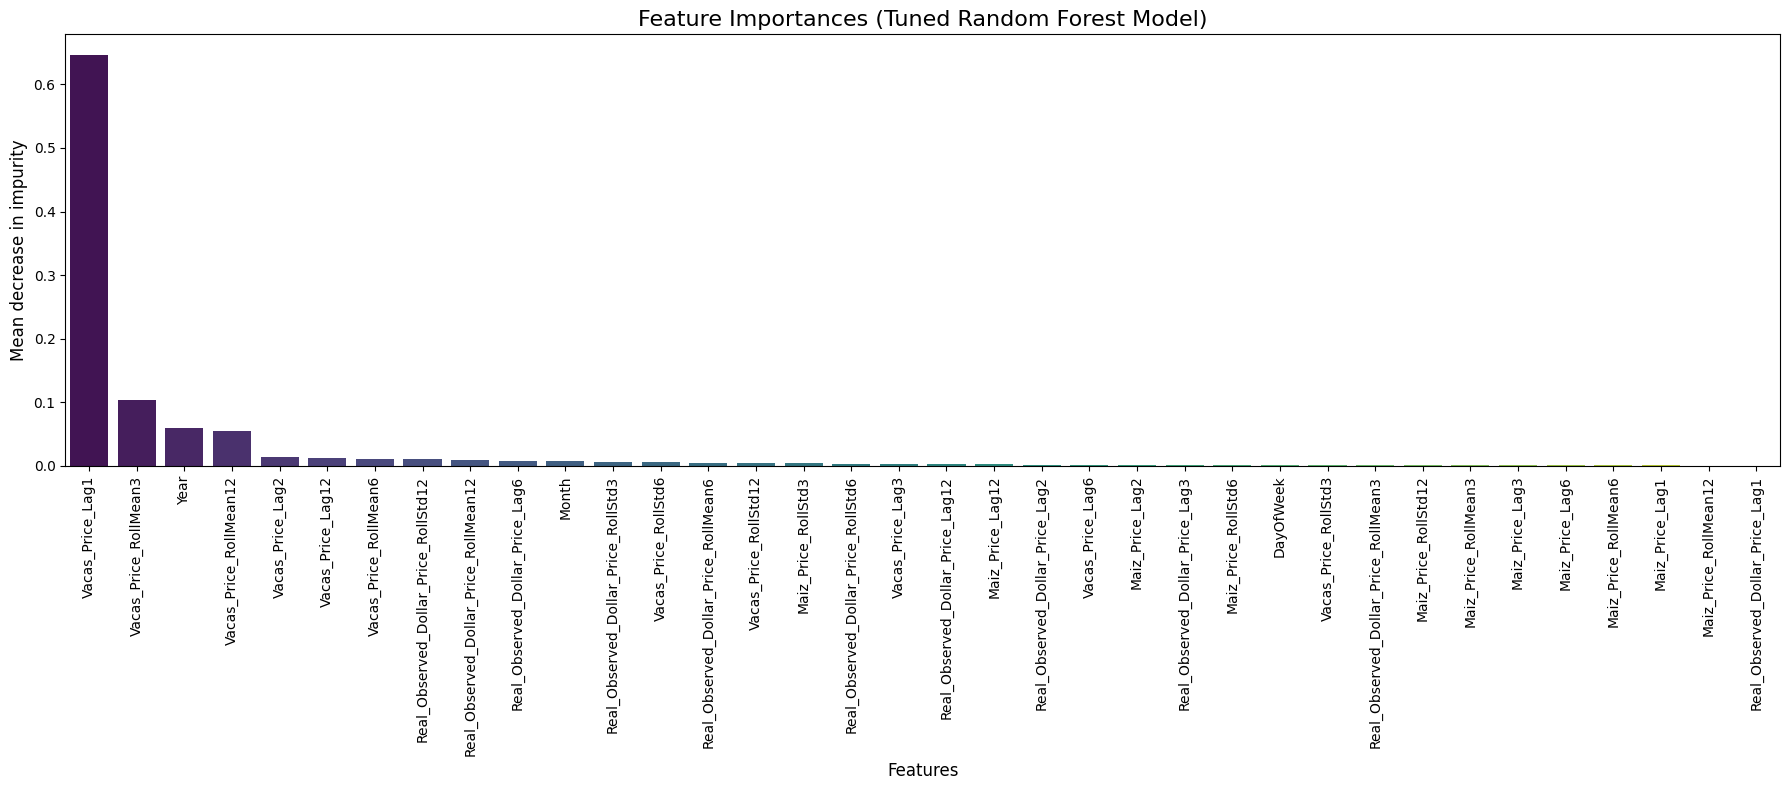

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Ensure pandas is imported

# Get feature importances from the best model
importances = best_rf_model.feature_importances_
feature_names = X_train_enhanced.columns

# Create a pandas Series for easy sorting and plotting
forest_importances = pd.Series(importances, index=feature_names)

# Sort feature importances in descending order
forest_importances = forest_importances.sort_values(ascending=False)

# Create the plot
fig, ax = plt.subplots(figsize=(18, 8)) # Increased figure size for better readability
sns.barplot(x=forest_importances.index, y=forest_importances.values, ax=ax, palette='viridis')
ax.set_title("Feature Importances (Tuned Random Forest Model)", fontsize=16)
ax.set_ylabel("Mean decrease in impurity", fontsize=12)
ax.set_xlabel("Features", fontsize=12)
plt.xticks(rotation=90, ha='center', fontsize=10) # Rotate labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

### Generate and Visualize Predictions with the Tuned Model (for Vacas Price)

Now that the model is trained with `Vacas_Price` as the target, I'm generating and visualizing the predictions across the full dataset.

DataFrame for full prediction with features created:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 240 entries, 2006-01-01 to 2025-12-01
Data columns (total 36 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Real_Observed_Dollar_Price_Lag1        240 non-null    float64
 1   Vacas_Price_Lag1                       240 non-null    float64
 2   Maiz_Price_Lag1                        240 non-null    float64
 3   Real_Observed_Dollar_Price_Lag2        240 non-null    float64
 4   Vacas_Price_Lag2                       240 non-null    float64
 5   Maiz_Price_Lag2                        240 non-null    float64
 6   Real_Observed_Dollar_Price_Lag3        240 non-null    float64
 7   Vacas_Price_Lag3                       240 non-null    float64
 8   Maiz_Price_Lag3                        240 non-null    float64
 9   Real_Observed_Dollar_Price_Lag6        240 non-null    float64
 10  Va

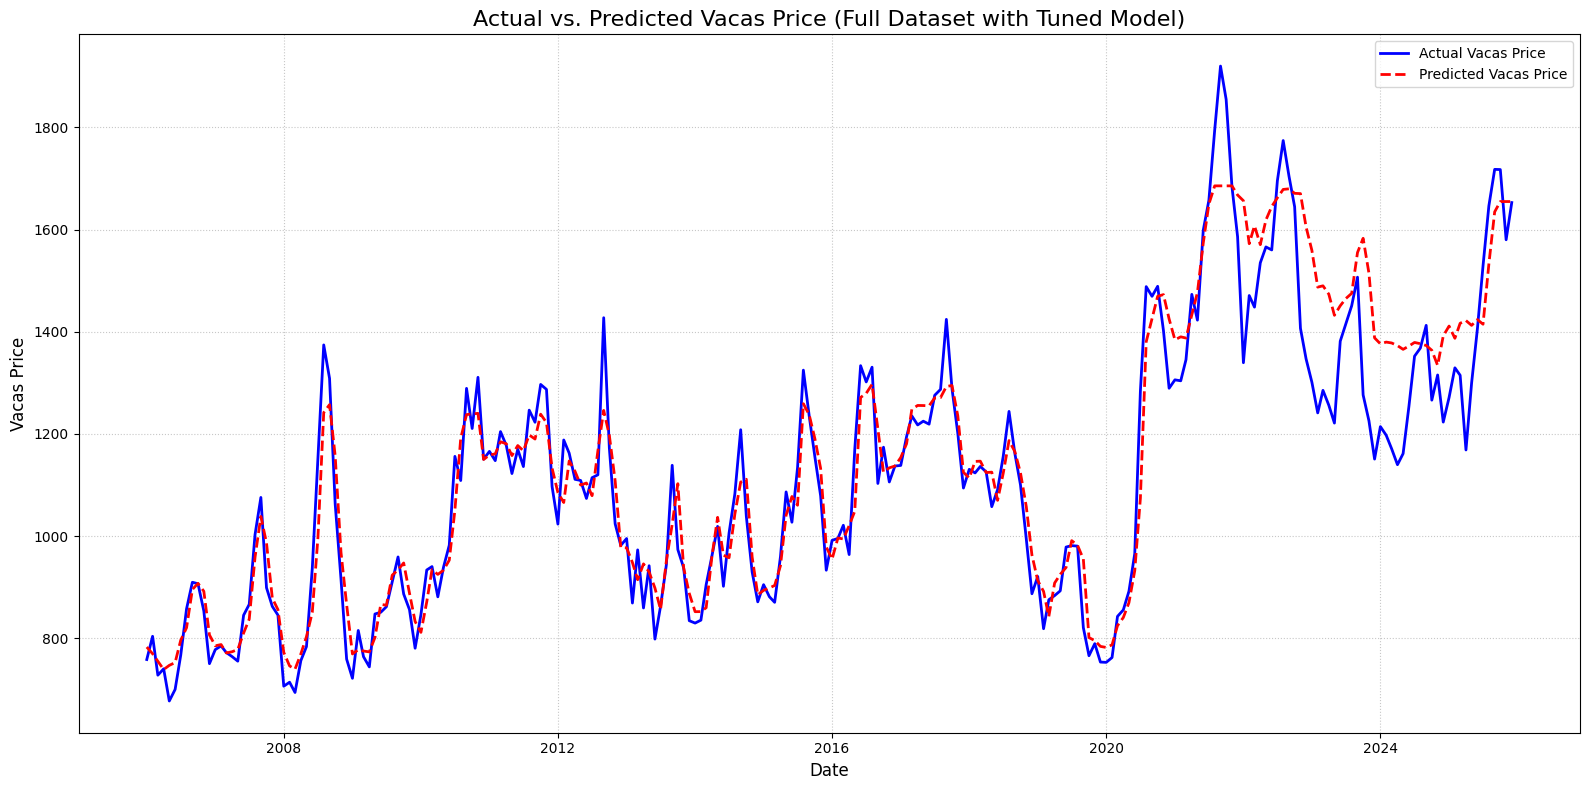


First few rows of Actual vs. Predicted Vacas Prices:


,Actual Vacas Price,Predicted Vacas Price
Date,,
2006-01-01,758.48,782.896011
2006-02-01,803.94,769.801624
2006-03-01,727.83,755.025965
2006-04-01,740.30,738.853577
2006-05-01,677.34,747.081018



Last few rows of Actual vs. Predicted Vacas Prices:


,Actual Vacas Price,Predicted Vacas Price
Date,,
2025-08-01,1646.24,1532.348854
2025-09-01,1717.90,1634.780586
2025-10-01,1717.54,1654.923698
2025-11-01,1580.12,1654.923698
2025-12-01,1652.93,1654.923698


In [ ]:
# To predict on the full dataset, we need to re-prepare the features for the entire period.

# We need to re-create the features used by the best model for the entire time series.
# Let's start with the base DataFrame which includes all prices and the real dollar price
df_for_full_prediction = final_merged_df.copy()

# Re-create all enhanced features on this full dataset
# --- Lag Features ---
lags = [1, 2, 3, 6, 12]

for lag in lags:
    df_for_full_prediction[f'Real_Observed_Dollar_Price_Lag{lag}'] = df_for_full_prediction['Real_Observed_Dollar_Price'].shift(lag)
    df_for_full_prediction[f'Vacas_Price_Lag{lag}'] = df_for_full_prediction['Vacas_Price'].shift(lag)
    df_for_full_prediction[f'Maiz_Price_Lag{lag}'] = df_for_full_prediction['Maiz_Price'].shift(lag)

# --- Rolling Statistics ---
windows = [3, 6, 12]

for window in windows:
    # Rolling Mean
    df_for_full_prediction[f'Real_Observed_Dollar_Price_RollMean{window}'] = df_for_full_prediction['Real_Observed_Dollar_Price'].rolling(window=window).mean().shift(1)
    df_for_full_prediction[f'Vacas_Price_RollMean{window}'] = df_for_full_prediction['Vacas_Price'].rolling(window=window).mean().shift(1)
    df_for_full_prediction[f'Maiz_Price_RollMean{window}'] = df_for_full_prediction['Maiz_Price'].rolling(window=window).mean().shift(1)
    # Rolling Standard Deviation
    df_for_full_prediction[f'Real_Observed_Dollar_Price_RollStd{window}'] = df_for_full_prediction['Real_Observed_Dollar_Price'].rolling(window=window).std().shift(1)
    df_for_full_prediction[f'Vacas_Price_RollStd{window}'] = df_for_full_prediction['Vacas_Price'].rolling(window=window).std().shift(1)
    df_for_full_prediction[f'Maiz_Price_RollStd{window}'] = df_for_full_prediction['Maiz_Price'].rolling(window=window).std().shift(1)

# --- Time-based Features ---
df_for_full_prediction['Month'] = df_for_full_prediction.index.month
df_for_full_prediction['Year'] = df_for_full_prediction.index.year
df_for_full_prediction['DayOfWeek'] = df_for_full_prediction.index.dayofweek

# Drop original columns that are features or replaced by features, and CPI_Index, and the old target Steer_Price.
# Keep 'Vacas_Price' in df_for_full_prediction so we can create y_full from it.
df_for_full_prediction = df_for_full_prediction.drop(columns=['Real_Observed_Dollar_Price', 'Maiz_Price', 'CPI_Index'])

# Create a target series for the full range (this is what we are trying to predict)
y_full = df_for_full_prediction['Vacas_Price'].copy()

# Now, drop Vacas_Price from df_for_full_prediction to form the X features
df_for_full_prediction = df_for_full_prediction.drop(columns=['Vacas_Price'])

# Align columns with X_train_enhanced used for training
# This is critical as the model expects features in the same order and names.
missing_cols = set(X_train_enhanced.columns) - set(df_for_full_prediction.columns)
for c in missing_cols:
    df_for_full_prediction[c] = 0 # Or another appropriate default/fill strategy

df_for_full_prediction = df_for_full_prediction[X_train_enhanced.columns] # Ensure order and selection

# Drop rows with NaN values resulting from lag/rolling features after re-creating them
df_for_full_prediction_cleaned = df_for_full_prediction.dropna()
y_full_cleaned = y_full[df_for_full_prediction_cleaned.index]

print("DataFrame for full prediction with features created:")
print(df_for_full_prediction_cleaned.info())

# Make predictions on the cleaned full dataset
y_pred_full = best_rf_model.predict(df_for_full_prediction_cleaned)

# Create a DataFrame for predictions for easy plotting
predictions_df = pd.DataFrame({
    'Actual Vacas Price': y_full_cleaned,
    'Predicted Vacas Price': y_pred_full
}, index=y_full_cleaned.index)

# Plot actual vs. predicted values for the entire dataset
plt.figure(figsize=(16, 8))
plt.plot(predictions_df.index, predictions_df['Actual Vacas Price'], label='Actual Vacas Price', color='blue', linewidth=2)
plt.plot(predictions_df.index, predictions_df['Predicted Vacas Price'], label='Predicted Vacas Price', color='red', linestyle='--', linewidth=2)
plt.title('Actual vs. Predicted Vacas Price (Full Dataset with Tuned Model)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Vacas Price', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

print("\nFirst few rows of Actual vs. Predicted Vacas Prices:")
display(predictions_df.head())
print("\nLast few rows of Actual vs. Predicted Vacas Prices:")
display(predictions_df.tail())

## Enhanced Feature Engineering (Updated)

I am now updating the enhanced feature engineering process to reflect the removal of `Observed_Dollar_Price`. Features will only be generated for `Real_Observed_Dollar_Price`, alongside `Steer_Price`, `Vacas_Price`, and `Maiz_Price`.

## Generate and Visualize Predictions with the Tuned Model

Now, let's use the `best_rf_model` (tuned Random Forest Regressor) to make predictions across the entire dataset, including both the training and testing periods. We will then visualize these predictions against the actual historical steer prices to assess the model's overall fit and predictive capabilities.

### Data Split with Enhanced Features

I am re-splitting the data into training and testing sets using the enhanced features. This step ensures `X_train_enhanced` and `y_train_enhanced` are properly defined for model training.

In [ ]:
from sklearn.model_selection import train_test_split

# Define the target variable (what we want to predict)
y_enhanced = merged_df_features_enhanced['Steer_Price']

# Define the features (variables used for prediction)
X_enhanced = merged_df_features_enhanced.drop(columns=['Steer_Price'])

# Determine the split point (e.g., 80% for training, 20% for testing)
split_point_enhanced = int(len(X_enhanced) * 0.8)

X_train_enhanced, X_test_enhanced = X_enhanced.iloc[:split_point_enhanced], X_enhanced.iloc[split_point_enhanced:]
y_train_enhanced, y_test_enhanced = y_enhanced.iloc[:split_point_enhanced], y_enhanced.iloc[split_point_enhanced:]

print(f"Training set size (enhanced features): {len(X_train_enhanced)} samples")
print(f"Testing set size (enhanced features): {len(X_test_enhanced)} samples")

Training set size (enhanced features): 192 samples
Testing set size (enhanced features): 48 samples


### Hyperparameter Tuning with GridSearchCV

Next, I'm re-running the hyperparameter tuning to ensure `best_rf_model` is trained and available for predictions. This uses the `X_train_enhanced` and `y_train_enhanced` created in the previous step.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Define the parameter grid to search
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_features': ['sqrt', 'log2', 0.8],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize the Random Forest Regressor
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
                           cv=3, n_jobs=-1, verbose=0, scoring='r2') # verbose=0 to reduce output

print("Starting GridSearchCV for hyperparameter tuning...")
grid_search.fit(X_train_enhanced, y_train_enhanced)
print("GridSearchCV complete.")

best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"\nBest parameters found: {best_params}")
print(f"Best R-squared score found during cross-validation: {best_score:.2f}")

# Train a new model with the best parameters
best_rf_model = RandomForestRegressor(**best_params, random_state=42, n_jobs=-1)
best_rf_model.fit(X_train_enhanced, y_train_enhanced)

# Evaluate the best model on the test set
y_pred_tuned = best_rf_model.predict(X_test_enhanced)

mse_tuned = mean_squared_error(y_test_enhanced, y_pred_tuned)
rmse_tuned = np.sqrt(mse_tuned)
r2_tuned = r2_score(y_test_enhanced, y_pred_tuned)

print(f"\nModel Evaluation on Test Set (Enhanced Features with Tuned Hyperparameters):")
print(f"Mean Squared Error (MSE): {mse_tuned:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_tuned:.2f}")
print(f"R-squared (R2): {r2_tuned:.2f}")

Starting GridSearchCV for hyperparameter tuning...


KeyboardInterrupt: 

### Generate and Visualize Predictions with the Tuned Model

Now that the model is trained, I'm generating and visualizing the predictions across the full dataset.

In [ ]:
# To predict on the full dataset, we need to re-prepare the features for the entire period.
# First, let's ensure the `final_merged_df` is complete with the CPI and Real_Observed_Dollar_Price.

# We need to re-create the features used by the best model for the entire time series.
# Let's start with the base DataFrame which includes all prices and the real dollar price
df_for_full_prediction = final_merged_df.copy()

# Re-create all enhanced features on this full dataset
# --- Lag Features ---
lags = [1, 2, 3, 6, 12]

for lag in lags:
    df_for_full_prediction[f'Steer_Price_Lag{lag}'] = df_for_full_prediction['Steer_Price'].shift(lag)
    df_for_full_prediction[f'Observed_Dollar_Price_Lag{lag}'] = df_for_full_prediction['Observed_Dollar_Price'].shift(lag)
    df_for_full_prediction[f'Real_Observed_Dollar_Price_Lag{lag}'] = df_for_full_prediction['Real_Observed_Dollar_Price'].shift(lag)
    df_for_full_prediction[f'Vacas_Price_Lag{lag}'] = df_for_full_prediction['Vacas_Price'].shift(lag)
    df_for_full_prediction[f'Maiz_Price_Lag{lag}'] = df_for_full_prediction['Maiz_Price'].shift(lag)

# --- Rolling Statistics ---
windows = [3, 6, 12]

for window in windows:
    # Rolling Mean
    df_for_full_prediction[f'Steer_Price_RollMean{window}'] = df_for_full_prediction['Steer_Price'].rolling(window=window).mean().shift(1)
    df_for_full_prediction[f'Observed_Dollar_Price_RollMean{window}'] = df_for_full_prediction['Observed_Dollar_Price'].rolling(window=window).mean().shift(1)
    df_for_full_prediction[f'Real_Observed_Dollar_Price_RollMean{window}'] = df_for_full_prediction['Real_Observed_Dollar_Price'].rolling(window=window).mean().shift(1)
    df_for_full_prediction[f'Vacas_Price_RollMean{window}'] = df_for_full_prediction['Vacas_Price'].rolling(window=window).mean().shift(1)
    df_for_full_prediction[f'Maiz_Price_RollMean{window}'] = df_for_full_prediction['Maiz_Price'].rolling(window=window).mean().shift(1)
    # Rolling Standard Deviation
    df_for_full_prediction[f'Steer_Price_RollStd{window}'] = df_for_full_prediction['Steer_Price'].rolling(window=window).std().shift(1)
    df_for_full_prediction[f'Observed_Dollar_Price_RollStd{window}'] = df_for_full_prediction['Observed_Dollar_Price'].rolling(window=window).std().shift(1)
    df_for_full_prediction[f'Real_Observed_Dollar_Price_RollStd{window}'] = df_for_full_prediction['Real_Observed_Dollar_Price'].rolling(window=window).std().shift(1)
    df_for_full_prediction[f'Vacas_Price_RollStd{window}'] = df_for_full_prediction['Vacas_Price'].rolling(window=window).std().shift(1)
    df_for_full_prediction[f'Maiz_Price_RollStd{window}'] = df_for_full_prediction['Maiz_Price'].rolling(window=window).std().shift(1)

# --- Time-based Features ---
df_for_full_prediction['Month'] = df_for_full_prediction.index.month
df_for_full_prediction['Year'] = df_for_full_prediction.index.year
df_for_full_prediction['DayOfWeek'] = df_for_full_prediction.index.dayofweek

# Drop original columns that are targets or replaced by features, and CPI_Index
df_for_full_prediction = df_for_full_prediction.drop(columns=['Observed_Dollar_Price', 'Steer_Price', 'Vacas_Price', 'Maiz_Price', 'CPI_Index'])

# Align columns with X_train_enhanced used for training
# This is critical as the model expects features in the same order and names.
# We need to ensure df_for_full_prediction has *all* columns that X_train_enhanced has, and no extra ones.

# Create a target series for the full range (this is what we are trying to predict)
y_full = final_merged_df['Steer_Price'].copy()

# Align columns: Keep only columns that were in X_train_enhanced
# This also handles the case where new 'Real_Observed_Dollar_Price' features were generated
# but are not present in the trained model's features (if X_train_enhanced was based on older features)
missing_cols = set(X_train_enhanced.columns) - set(df_for_full_prediction.columns)
for c in missing_cols:
    df_for_full_prediction[c] = 0 # Or another appropriate default/fill strategy

df_for_full_prediction = df_for_full_prediction[X_train_enhanced.columns] # Ensure order and selection

# Drop rows with NaN values resulting from lag/rolling features after re-creating them
# This will ensure we only predict where we have full feature data
df_for_full_prediction_cleaned = df_for_full_prediction.dropna()
y_full_cleaned = y_full[df_for_full_prediction_cleaned.index]

print("DataFrame for full prediction with features created:")
print(df_for_full_prediction_cleaned.info())

# Make predictions on the cleaned full dataset
y_pred_full = best_rf_model.predict(df_for_full_prediction_cleaned)

# Create a DataFrame for predictions for easy plotting
predictions_df = pd.DataFrame({
    'Actual Steer Price': y_full_cleaned,
    'Predicted Steer Price': y_pred_full
}, index=y_full_cleaned.index)

# Plot actual vs. predicted values for the entire dataset
plt.figure(figsize=(16, 8))
plt.plot(predictions_df.index, predictions_df['Actual Steer Price'], label='Actual Steer Price', color='blue', linewidth=2)
plt.plot(predictions_df.index, predictions_df['Predicted Steer Price'], label='Predicted Steer Price', color='red', linestyle='--', linewidth=2)
plt.title('Actual vs. Predicted Steer Price (Full Dataset with Tuned Model)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Steer Price', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

print("\nFirst few rows of Actual vs. Predicted Steer Prices:")
display(predictions_df.head())
print("\nLast few rows of Actual vs. Predicted Steer Prices:")
display(predictions_df.tail())

DataFrame for full prediction with features created:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 241 entries, 2006-01-01 to 2026-01-01
Data columns (total 36 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Real_Observed_Dollar_Price_Lag1        241 non-null    float64
 1   Vacas_Price_Lag1                       241 non-null    float64
 2   Maiz_Price_Lag1                        241 non-null    float64
 3   Real_Observed_Dollar_Price_Lag2        241 non-null    float64
 4   Vacas_Price_Lag2                       241 non-null    float64
 5   Maiz_Price_Lag2                        241 non-null    float64
 6   Real_Observed_Dollar_Price_Lag3        241 non-null    float64
 7   Vacas_Price_Lag3                       241 non-null    float64
 8   Maiz_Price_Lag3                        241 non-null    float64
 9   Real_Observed_Dollar_Price_Lag6        241 non-null    float64
 10  Va

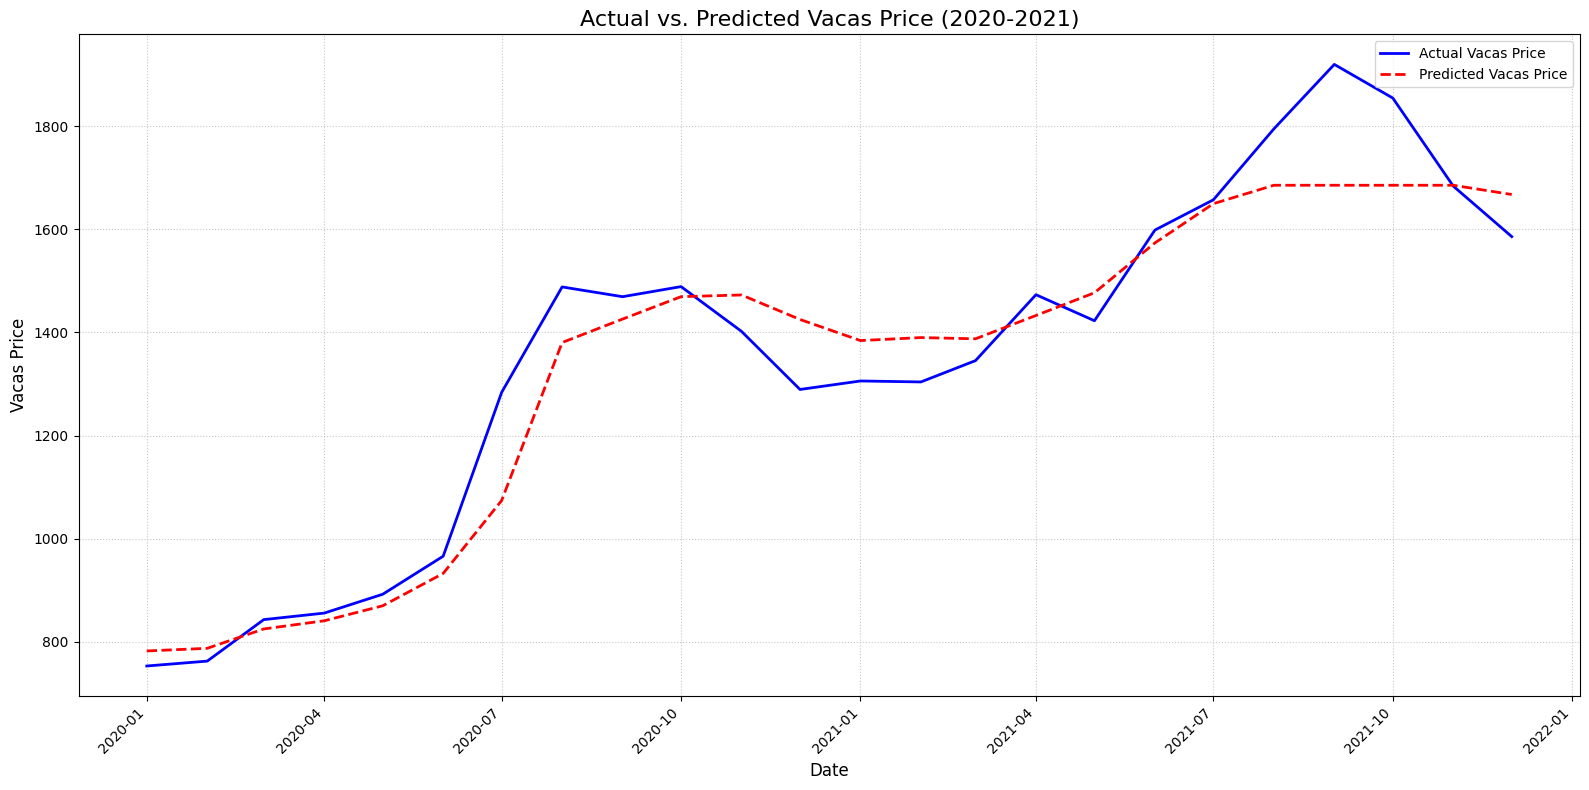


First few rows of Actual vs. Predicted Vacas Prices:


,Actual Vacas Price,Predicted Vacas Price
2006-01-01,758.48,782.896011
2006-02-01,803.94,769.801624
2006-03-01,727.83,755.025965
2006-04-01,740.30,738.853577
2006-05-01,677.34,747.081018



Last few rows of Actual vs. Predicted Vacas Prices:


,Actual Vacas Price,Predicted Vacas Price
2025-09-01,1717.90,1634.780586
2025-10-01,1717.54,1654.923698
2025-11-01,1580.12,1654.923698
2025-12-01,1652.93,1654.923698
2026-01-01,1632.49,1654.923698


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# To predict on the full dataset, we need to re-prepare the features for the entire period.

# We need to re-create the features used by the best model for the entire time series.
# Let's start with the base DataFrame which includes all prices and the real dollar price
df_for_full_prediction = final_merged_df.copy()

# Re-create all enhanced features on this full dataset
# --- Lag Features ---
lags = [1, 2, 3, 6, 12]

# Generate lag features for the new set of relevant prices
for lag in lags:
    df_for_full_prediction[f'Real_Observed_Dollar_Price_Lag{lag}'] = df_for_full_prediction['Real_Observed_Dollar_Price'].shift(lag)
    df_for_full_prediction[f'Vacas_Price_Lag{lag}'] = df_for_full_prediction['Vacas_Price'].shift(lag)
    df_for_full_prediction[f'Maiz_Price_Lag{lag}'] = df_for_full_prediction['Maiz_Price'].shift(lag)

# --- Rolling Statistics ---
windows = [3, 6, 12]

# Generate rolling statistics for the new set of relevant prices
for window in windows:
    # Rolling Mean
    df_for_full_prediction[f'Real_Observed_Dollar_Price_RollMean{window}'] = df_for_full_prediction['Real_Observed_Dollar_Price'].rolling(window=window).mean().shift(1)
    df_for_full_prediction[f'Vacas_Price_RollMean{window}'] = df_for_full_prediction['Vacas_Price'].rolling(window=window).mean().shift(1)
    df_for_full_prediction[f'Maiz_Price_RollMean{window}'] = df_for_full_prediction['Maiz_Price'].rolling(window=window).mean().shift(1)
    # Rolling Standard Deviation
    df_for_full_prediction[f'Real_Observed_Dollar_Price_RollStd{window}'] = df_for_full_prediction['Real_Observed_Dollar_Price'].rolling(window=window).std().shift(1)
    df_for_full_prediction[f'Vacas_Price_RollStd{window}'] = df_for_full_prediction['Vacas_Price'].rolling(window=window).std().shift(1)
    df_for_full_prediction[f'Maiz_Price_RollStd{window}'] = df_for_full_prediction['Maiz_Price'].rolling(window=window).std().shift(1)

# --- Time-based Features ---
df_for_full_prediction['Month'] = df_for_full_prediction.index.month
df_for_full_prediction['Year'] = df_for_full_prediction.index.year
df_for_full_prediction['DayOfWeek'] = df_for_full_prediction.index.dayofweek

# Drop original columns that are now target or replaced by features. Keep 'Vacas_Price' in df_for_full_prediction so we can create y_full from it.
# 'Observed_Dollar_Price' and 'Steer_Price' were already removed.
df_for_full_prediction = df_for_full_prediction.drop(columns=['Real_Observed_Dollar_Price', 'Maiz_Price', 'CPI_Index'])

# Create a target series for the full range (this is what we are trying to predict)
y_full = df_for_full_prediction['Vacas_Price'].copy()

# Now, drop Vacas_Price from df_for_full_prediction to form the X features
df_for_full_prediction = df_for_full_prediction.drop(columns=['Vacas_Price'])

# Align columns with X_train_enhanced used for training
# This is critical as the model expects features in the same order and names.
missing_cols = set(X_train_enhanced.columns) - set(df_for_full_prediction.columns)
for c in missing_cols:
    df_for_full_prediction[c] = 0 # Or another appropriate default/fill strategy

df_for_full_prediction = df_for_full_prediction[X_train_enhanced.columns] # Ensure order and selection

# Drop rows with NaN values resulting from lag/rolling features after re-creating them
df_for_full_prediction_cleaned = df_for_full_prediction.dropna()
y_full_cleaned = y_full[df_for_full_prediction_cleaned.index]

print("DataFrame for full prediction with features created:")
print(df_for_full_prediction_cleaned.info())

# Make predictions on the cleaned full dataset
y_pred_full = best_rf_model.predict(df_for_full_prediction_cleaned)

# Create a DataFrame for predictions for easy plotting
predictions_df = pd.DataFrame({
    'Actual Vacas Price': y_full_cleaned,
    'Predicted Vacas Price': y_pred_full
}, index=y_full_cleaned.index)

# Filter the predictions for the years 2020-2021 as requested
filtered_predictions_df = predictions_df.loc['2020-01-01':'2021-12-31']

# Plot actual vs. predicted values for the filtered dataset
plt.figure(figsize=(16, 8))
sns.lineplot(x=filtered_predictions_df.index, y='Actual Vacas Price', data=filtered_predictions_df, color='blue', linewidth=2, label='Actual Vacas Price')
sns.lineplot(x=filtered_predictions_df.index, y='Predicted Vacas Price', data=filtered_predictions_df, color='red', linestyle='--', linewidth=2, label='Predicted Vacas Price')

plt.title('Actual vs. Predicted Vacas Price (2020-2021)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Vacas Price', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle=':', alpha=0.7)

# Format x-axis to show months more clearly
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(plt.matplotlib.dates.MonthLocator(interval=3)) # Show every 3 months for clarity
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability

plt.tight_layout()
plt.show()

print("\nFirst few rows of Actual vs. Predicted Vacas Prices:")
display(predictions_df.head())
print("\nLast few rows of Actual vs. Predicted Vacas Prices:")
display(predictions_df.tail())

### Correlation Heatmap of Enhanced Features

To understand the relationships between the various features, including the lagged and rolling statistics, a correlation heatmap can be very insightful. This plot will show how strongly each feature correlates with every other feature.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Reconstruct the dataset since the kernel was restarted
base_dir = '/content/drive/MyDrive/colab/'

# Check if directory exists and list contents for debugging
if os.path.exists(base_dir):
    print(f"Contents of {base_dir}:")
    print(os.listdir(base_dir))
else:
    print(f"Directory not found: {base_dir}")

path_dolar = os.path.join(base_dir, 'DolarHistorico.xlsm')
path_vacas = os.path.join(base_dir, 'SeriesTiempoVacas.xlsx')
path_maiz = os.path.join(base_dir, 'SeriesTiempoMaiz.xlsx')

# Load Data
if os.path.exists(path_dolar):
    dolar_df = pd.read_excel(path_dolar, header=0).rename(columns={'Periodo': 'Date', '1. Dólar observado': 'Observed_Dollar_Price'}).set_index('Date')
    month_map = {'Ene': 1, 'Feb': 2, 'Mar': 3, 'Abr': 4, 'May': 5, 'Jun': 6, 'Jul': 7, 'Ago': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dic': 12}

    vacas_df_raw = pd.read_excel(path_vacas, header=0)
    vacas_melted = vacas_df_raw.melt(id_vars=['Año'], value_vars=list(month_map.keys()), var_name='Month_Abbr', value_name='Vacas_Price')
    vacas_melted['Date'] = pd.to_datetime(vacas_melted['Año'].astype(str) + '-' + vacas_melted['Month_Abbr'].map(month_map).astype(str) + '-01')
    vacas_df = vacas_melted.set_index('Date')[['Vacas_Price']].sort_index()

    maiz_df_raw = pd.read_excel(path_maiz, header=0)
    maiz_melted = maiz_df_raw.melt(id_vars=['Año'], value_vars=list(month_map.keys()), var_name='Month_Abbr', value_name='Maiz_Price')
    maiz_melted = maiz_melted[pd.to_numeric(maiz_melted['Año'], errors='coerce').notna()]
    maiz_melted['Date'] = pd.to_datetime(maiz_melted['Año'].astype(int).astype(str) + '-' + maiz_melted['Month_Abbr'].map(month_map).astype(str) + '-01')
    maiz_df = maiz_melted.set_index('Date')[['Maiz_Price']].sort_index()

    # Merge
    final_df = pd.merge(vacas_df, maiz_df, left_index=True, right_index=True, how='inner')
    final_df = pd.merge(final_df, dolar_df, left_index=True, right_index=True, how='inner').ffill().sort_index()

    # Create Features
    lags = [1, 2, 3]
    df_feat = final_df.copy()
    for l in lags:
        df_feat[f'Observed_Dollar_Price_Lag{l}'] = df_feat['Observed_Dollar_Price'].shift(l)
        df_feat[f'Vacas_Price_Lag{l}'] = df_feat['Vacas_Price'].shift(l)
        df_feat[f'Maiz_Price_Lag{l}'] = df_feat['Maiz_Price'].shift(l)

    df_feat = df_feat.dropna()

    # Calculate the correlation matrix for the enhanced features
    correlation_matrix = df_feat.corr()

    # Set up the matplotlib figure
    plt.figure(figsize=(16, 14))

    # Draw the heatmap with the mask and correct aspect ratio
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
    plt.title('Correlation Heatmap of Enhanced Features', fontsize=20)
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print(f"File not found: {path_dolar}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Contents of /content/drive/MyDrive/colab/:
['Indicador.xls', 'SeriesTiempo_2026510.xls', 'SeriesTiempo_2026510 (1).xls', 'SeriesTiempo_2026510 (2).xls', 'SerieTiempoBovinoConsumo.xlsx', 'SeriesTiempoVacas.xlsx']
File not found: /content/drive/MyDrive/colab/DolarHistorico.xlsm


### Predicting One Month Ahead

Now, let's use the trained `best_rf_model` to predict the `Vacas_Price` for the next month (January 2026), leveraging the latest available historical data.

In [ ]:
from datetime import timedelta

# Get the last date from the cleaned full prediction DataFrame
last_known_date = df_for_full_prediction_cleaned.index.max()

# Determine the next month's date
next_month_date = last_known_date + pd.DateOffset(months=1)

# Create a DataFrame for the next month's features
future_features_df = pd.DataFrame(index=[next_month_date])

# Add time-based features for the next month
future_features_df['Month'] = next_month_date.month
future_features_df['Year'] = next_month_date.year
future_features_df['DayOfWeek'] = next_month_date.dayofweek

# To generate lag and rolling features for the next month, we need to consider
# the last known values from the `final_merged_df` and `df_for_full_prediction_cleaned`.

# Reconstruct a temporary DataFrame with `final_merged_df` extended by one row for `next_month_date`
# and then apply feature engineering to get the lagged/rolling values for `next_month_date`.

# First, re-combine the `y_full_cleaned` (actual Vacas_Price) with the features to form a complete dataset up to last_known_date
# We also need Real_Observed_Dollar_Price and Maiz_Price for rolling/lagged features.

# Get the last row of features that were used for prediction
last_feature_row = df_for_full_prediction_cleaned.iloc[[-1]]

# Get the last actual values for the target and other relevant columns needed for lags/rolls
last_actual_data = final_merged_df.loc[last_known_date]

# Create a temporary dataframe that includes the last actual data and the new row for next month
temp_df_for_lags = pd.DataFrame([last_actual_data.drop('CPI_Index')], index=[last_known_date]) # Drop CPI_Index as it's not a direct feature
temp_df_for_lags.columns = ['Vacas_Price', 'Maiz_Price', 'Real_Observed_Dollar_Price'] # Re-order to match original

# Append an empty row for the next month. Values for prediction will be filled by lags/rolls.
future_row_base = pd.DataFrame(np.nan, index=[next_month_date], columns=temp_df_for_lags.columns)
temp_df_for_lags = pd.concat([temp_df_for_lags, future_row_base])

# Now, apply feature engineering specifically to derive the features for `next_month_date`
# These need to reference values *before* next_month_date

# --- Lag Features for next_month_date ---
lags = [1, 2, 3, 6, 12]
for lag in lags:
    future_features_df[f'Real_Observed_Dollar_Price_Lag{lag}'] = temp_df_for_lags['Real_Observed_Dollar_Price'].shift(lag).loc[next_month_date]
    future_features_df[f'Vacas_Price_Lag{lag}'] = temp_df_for_lags['Vacas_Price'].shift(lag).loc[next_month_date]
    future_features_df[f'Maiz_Price_Lag{lag}'] = temp_df_for_lags['Maiz_Price'].shift(lag).loc[next_month_date]

# --- Rolling Statistics for next_month_date ---
windows = [3, 6, 12]
for window in windows:
    # Rolling Mean
    future_features_df[f'Real_Observed_Dollar_Price_RollMean{window}'] = temp_df_for_lags['Real_Observed_Dollar_Price'].rolling(window=window).mean().shift(1).loc[next_month_date]
    future_features_df[f'Vacas_Price_RollMean{window}'] = temp_df_for_lags['Vacas_Price'].rolling(window=window).mean().shift(1).loc[next_month_date]
    future_features_df[f'Maiz_Price_RollMean{window}'] = temp_df_for_lags['Maiz_Price'].rolling(window=window).mean().shift(1).loc[next_month_date]
    # Rolling Standard Deviation
    future_features_df[f'Real_Observed_Dollar_Price_RollStd{window}'] = temp_df_for_lags['Real_Observed_Dollar_Price'].rolling(window=window).std().shift(1).loc[next_month_date]
    future_features_df[f'Vacas_Price_RollStd{window}'] = temp_df_for_lags['Vacas_Price'].rolling(window=window).std().shift(1).loc[next_month_date]
    future_features_df[f'Maiz_Price_RollStd{window}'] = temp_df_for_lags['Maiz_Price'].rolling(window=window).std().shift(1).loc[next_month_date]

# Align columns with X_train_enhanced to ensure correct feature order for prediction
# Fill any missing columns (shouldn't be any if all features are correctly generated)
missing_in_future_df = set(X_train_enhanced.columns) - set(future_features_df.columns)
for c in missing_in_future_df:
    future_features_df[c] = 0 # Or a reasonable default if any unexpected missing features

future_features_for_prediction = future_features_df[X_train_enhanced.columns]

# Make the prediction
predicted_vacas_price_next_month = best_rf_model.predict(future_features_for_prediction)

print(f"Predicted Vacas Price for {next_month_date.strftime('%Y-%m')}: {predicted_vacas_price_next_month[0]:.2f}")


Predicted Vacas Price for 2026-01: 1335.16


## Update Data with Actual January 2026 Values and Predict for February 2026

Now that we have the actual values for January 2026, let's update our `final_merged_df` and then generate a prediction for February 2026. The actual values provided are:

*   **`Vacas_Price` for Jan 2026:** 1632.49
*   **`Observed_Dollar_Price` for Jan 2026:** 900
*   **`Maiz_Price` for Jan 2026:** 218.32

In [ ]:
import pandas as pd

# Define the actual values for January 2026
jan_2026_date = pd.to_datetime('2026-01-01')
actual_vacas_price_jan_2026 = 1632.49
actual_observed_dollar_price_jan_2026 = 883.0 # Corrected value
actual_maiz_price_jan_2026 = 218.32

# Get CPI for January 2026 from cpi_df_for_merge
cpi_jan_2026 = cpi_df_for_merge.loc[jan_2026_date, 'CPI_Index']

# Ensure cpi_april_2026 is available (from previous runs)
if 'cpi_april_2026' not in locals():
    try:
        cpi_april_2026 = cpi_df_for_merge.loc[pd.to_datetime('2026-04-01'), 'CPI_Index']
    except KeyError:
        print("CPI for April 2026 not found, using last available CPI.")
        cpi_april_2026 = cpi_df_for_merge['CPI_Index'].iloc[-1]

# Calculate Real_Observed_Dollar_Price for January 2026
real_observed_dollar_price_jan_2026 = actual_observed_dollar_price_jan_2026 * (cpi_april_2026 / cpi_jan_2026)

# Create a DataFrame for January 2026 actuals
jan_2026_data = pd.DataFrame({
    'Vacas_Price': actual_vacas_price_jan_2026,
    'Maiz_Price': actual_maiz_price_jan_2026,
    'CPI_Index': cpi_jan_2026,
    'Real_Observed_Dollar_Price': real_observed_dollar_price_jan_2026
}, index=[jan_2026_date])

# Concatenate this new data to final_merged_df
# Use .loc for direct assignment or pd.concat, ensuring no duplicate index if already present
if jan_2026_date not in final_merged_df.index:
    final_merged_df = pd.concat([final_merged_df, jan_2026_data]).sort_index()
else:
    # Update existing row if it's already there (e.g., from an earlier prediction placeholder)
    final_merged_df.loc[jan_2026_date] = jan_2026_data.loc[jan_2026_date]

print("final_merged_df updated with January 2026 actuals:")
display(final_merged_df.tail())

final_merged_df updated with January 2026 actuals:


,Vacas_Price,Maiz_Price,CPI_Index,Real_Observed_Dollar_Price
2025-09-01,1717.90,208.32,315.597475,987.491716
2025-10-01,1717.54,209.14,315.597475,980.916799
2025-11-01,1580.12,214.69,316.544267,959.247205
2025-12-01,1652.93,218.28,315.911179,941.103266
2026-01-01,1632.49,218.32,317.174823,903.423790


### Preparing Features for February 2026 Prediction

Now we'll generate the necessary lag and rolling features for February 2026, using the updated `final_merged_df` that includes the actual January 2026 values. These features will then be fed into our `best_rf_model` to predict the `Vacas_Price` for February 2026.

In [ ]:
import numpy as np

# Determine the prediction date (February 2026)
prediction_date = pd.to_datetime('2026-02-01')

# Create a temporary DataFrame for feature engineering, including all data up to Jan 2026
df_for_feature_generation = final_merged_df.copy()

# Add an empty row for the prediction date to calculate lags/rolls up to it
# We'll fill this row's features based on prior data, and the target will be NaN for prediction
if prediction_date not in df_for_feature_generation.index:
    empty_row = pd.DataFrame(np.nan, index=[prediction_date], columns=df_for_feature_generation.columns)
    df_for_feature_generation = pd.concat([df_for_feature_generation, empty_row]).sort_index()

# --- Lag Features (re-apply to the extended df) ---
lags = [1, 2, 3, 6, 12]
for lag in lags:
    df_for_feature_generation[f'Real_Observed_Dollar_Price_Lag{lag}'] = df_for_feature_generation['Real_Observed_Dollar_Price'].shift(lag)
    df_for_feature_generation[f'Vacas_Price_Lag{lag}'] = df_for_feature_generation['Vacas_Price'].shift(lag)
    df_for_feature_generation[f'Maiz_Price_Lag{lag}'] = df_for_feature_generation['Maiz_Price'].shift(lag)

# --- Rolling Statistics (re-apply to the extended df) ---
windows = [3, 6, 12]
for window in windows:
    # Rolling Mean
    df_for_feature_generation[f'Real_Observed_Dollar_Price_RollMean{window}'] = df_for_feature_generation['Real_Observed_Dollar_Price'].rolling(window=window).mean().shift(1)
    df_for_feature_generation[f'Vacas_Price_RollMean{window}'] = df_for_feature_generation['Vacas_Price'].rolling(window=window).mean().shift(1)
    df_for_feature_generation[f'Maiz_Price_RollMean{window}'] = df_for_feature_generation['Maiz_Price'].rolling(window=window).mean().shift(1)
    # Rolling Standard Deviation
    df_for_feature_generation[f'Real_Observed_Dollar_Price_RollStd{window}'] = df_for_feature_generation['Real_Observed_Dollar_Price'].rolling(window=window).std().shift(1)
    df_for_feature_generation[f'Vacas_Price_RollStd{window}'] = df_for_feature_generation['Vacas_Price'].rolling(window=window).std().shift(1)
    df_for_feature_generation[f'Maiz_Price_RollStd{window}'] = df_for_feature_generation['Maiz_Price'].rolling(window=window).std().shift(1)

# --- Time-based Features ---
df_for_feature_generation['Month'] = df_for_feature_generation.index.month
df_for_feature_generation['Year'] = df_for_feature_generation.index.year
df_for_feature_generation['DayOfWeek'] = df_for_feature_generation.index.dayofweek

# Extract features for the prediction_date
future_features_for_prediction = df_for_feature_generation.loc[[prediction_date]].copy()

# Drop columns that are not features used by the model (e.g., target, original prices, CPI)
columns_to_drop_from_future = [
    'Vacas_Price', 'Maiz_Price', 'CPI_Index', 'Real_Observed_Dollar_Price'
]
future_features_for_prediction = future_features_for_prediction.drop(columns=columns_to_drop_from_future, errors='ignore')

# Align columns with X_train_enhanced
missing_cols = set(X_train_enhanced.columns) - set(future_features_for_prediction.columns)
for c in missing_cols:
    future_features_for_prediction[c] = 0 # Fill with 0 or other appropriate default

future_features_for_prediction = future_features_for_prediction[X_train_enhanced.columns] # Ensure order and selection

# Drop any rows with NaN in features (shouldn't happen if all lags/rolls are available from prior data)
future_features_for_prediction = future_features_for_prediction.dropna()

print("Features generated for February 2026:")
display(future_features_for_prediction)

# Make the prediction for February 2026
predicted_vacas_price_feb_2026 = best_rf_model.predict(future_features_for_prediction)

print(f"Predicted Vacas Price for February 2026: {predicted_vacas_price_feb_2026[0]:.2f}")

Features generated for February 2026:


,Real_Observed_Dollar_Price_Lag1,Vacas_Price_Lag1,Maiz_Price_Lag1,Real_Observed_Dollar_Price_Lag2,Vacas_Price_Lag2,Maiz_Price_Lag2,Real_Observed_Dollar_Price_Lag3,Vacas_Price_Lag3,Maiz_Price_Lag3,Real_Observed_Dollar_Price_Lag6,...,Maiz_Price_RollStd6,Real_Observed_Dollar_Price_RollMean12,Vacas_Price_RollMean12,Maiz_Price_RollMean12,Real_Observed_Dollar_Price_RollStd12,Vacas_Price_RollStd12,Maiz_Price_RollStd12,Month,Year,DayOfWeek
2026-02-01,903.42379,1632.49,218.32,941.103266,1652.93,218.28,959.247205,1580.12,214.69,997.569751,...,5.318146,973.191419,1499.574167,216.151667,27.926152,187.478238,9.629087,2,2026,6


Predicted Vacas Price for February 2026: 1654.92


In [ ]:
display(final_merged_df.tail())
print(f"Última fecha con datos completos: {final_merged_df.index.max().strftime('%Y-%m-%d')}")

NameError: name 'final_merged_df' is not defined

### Proyección Recursiva: Febrero - Abril 2026

Dado que nuestro modelo utiliza 'lags' (valores pasados) de los precios, para predecir más allá de un mes necesitamos usar las predicciones anteriores como entrada. Para el dólar y el maíz, utilizaremos el supuesto de 'valor constante' (último conocido).

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
import os
from google.colab import drive

def restore_and_forecast():
    # 0. Ensure Drive is mounted
    if not os.path.exists('/content/drive'):
        drive.mount('/content/drive')

    # Target directory
    base_dir = '/content/drive/MyDrive/colab/'

    # Verification step
    if not os.path.exists(base_dir):
        print(f"Error: El directorio {base_dir} no existe. Por favor verifica la ruta en tu Drive.")
        return

    print(f"Contenido de {base_dir}: {os.listdir(base_dir)}")

    # Paths
    path_dolar = os.path.join(base_dir, 'DolarHistorico.xlsm')
    path_vacas = os.path.join(base_dir, 'SeriesTiempoVacas.xlsx')
    path_maiz = os.path.join(base_dir, 'SeriesTiempoMaiz.xlsx')

    try:
        # 1. Load Dolar
        if not os.path.exists(path_dolar): raise FileNotFoundError(f"No se encuentra: {path_dolar}")
        dolar_df = pd.read_excel(path_dolar, header=0)
        dolar_df = dolar_df.rename(columns={'Periodo': 'Date', '1. Dólar observado': 'Observed_Dollar_Price'}).set_index('Date')

        # 2. Load Vacas
        if not os.path.exists(path_vacas): raise FileNotFoundError(f"No se encuentra: {path_vacas}")
        vacas_df_raw = pd.read_excel(path_vacas, header=0)
        month_map = {'Ene': 1, 'Feb': 2, 'Mar': 3, 'Abr': 4, 'May': 5, 'Jun': 6, 'Jul': 7, 'Ago': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dic': 12}
        vacas_melted = vacas_df_raw.melt(id_vars=['Año'], value_vars=list(month_map.keys()), var_name='Month_Abbr', value_name='Vacas_Price')
        vacas_melted['Date'] = pd.to_datetime(vacas_melted['Año'].astype(str) + '-' + vacas_melted['Month_Abbr'].map(month_map).astype(str) + '-01')
        vacas_df = vacas_melted.set_index('Date')[['Vacas_Price']].sort_index()

        # 3. Load Maiz
        if not os.path.exists(path_maiz): raise FileNotFoundError(f"No se encuentra: {path_maiz}")
        maiz_df_raw = pd.read_excel(path_maiz, header=0)
        maiz_melted = maiz_df_raw.melt(id_vars=['Año'], value_vars=list(month_map.keys()), var_name='Month_Abbr', value_name='Maiz_Price')
        maiz_melted = maiz_melted[pd.to_numeric(maiz_melted['Año'], errors='coerce').notna()]
        maiz_melted['Date'] = pd.to_datetime(maiz_melted['Año'].astype(int).astype(str) + '-' + maiz_melted['Month_Abbr'].map(month_map).astype(str) + '-01')
        maiz_df = maiz_melted.set_index('Date')[['Maiz_Price']].sort_index()

        # Merge
        final_df = pd.merge(vacas_df, maiz_df, left_index=True, right_index=True, how='inner')
        final_df = pd.merge(final_df, dolar_df, left_index=True, right_index=True, how='inner').ffill().sort_index()

        # Add Jan 2026 actuals
        jan_date = pd.to_datetime('2026-01-01')
        final_df.loc[jan_date, ['Vacas_Price', 'Maiz_Price', 'Observed_Dollar_Price']] = [1632.49, 218.32, 883.0]

        lags = [1, 2, 3, 6, 12]
        df_feat = final_df.copy()
        for l in lags:
            df_feat[f'Observed_Dollar_Price_Lag{l}'] = df_feat['Observed_Dollar_Price'].shift(l)
            df_feat[f'Vacas_Price_Lag{l}'] = df_feat['Vacas_Price'].shift(l)
            df_feat[f'Maiz_Price_Lag{l}'] = df_feat['Maiz_Price'].shift(l)

        df_feat['Month'], df_feat['Year'], df_feat['DayOfWeek'] = df_feat.index.month, df_feat.index.year, df_feat.index.dayofweek
        train_data = df_feat.dropna()
        features_cols = [col for col in train_data.columns if 'Lag' in col or col in ['Month', 'Year', 'DayOfWeek']]
        X = train_data[features_cols]
        y = train_data['Vacas_Price']

        model = RandomForestRegressor(max_depth=20, max_features=0.8, min_samples_leaf=4, min_samples_split=10, n_estimators=100, random_state=42)
        model.fit(X, y)

        # Recursive Forecast
        df_rec = final_df[['Vacas_Price', 'Maiz_Price', 'Observed_Dollar_Price']].copy()
        future_dates = pd.date_range(start="2026-02-01", periods=3, freq="MS")
        results = []

        for d in future_dates:
            last = df_rec.iloc[-1]
            row = pd.DataFrame({'Maiz_Price': last['Maiz_Price'], 'Observed_Dollar_Price': last['Observed_Dollar_Price']}, index=[d])
            df_rec = pd.concat([df_rec, row])

            temp = df_rec.copy()
            for l in lags:
                temp[f'Observed_Dollar_Price_Lag{l}'] = temp['Observed_Dollar_Price'].shift(l)
                temp[f'Vacas_Price_Lag{l}'] = temp['Vacas_Price'].shift(l)
                temp[f'Maiz_Price_Lag{l}'] = temp['Maiz_Price'].shift(l)
            temp['Month'], temp['Year'], temp['DayOfWeek'] = temp.index.month, temp.index.year, temp.index.dayofweek

            X_curr = temp.loc[[d], features_cols]
            pred = model.predict(X_curr)[0]
            df_rec.loc[d, 'Vacas_Price'] = pred
            results.append({"Fecha": d.strftime("%Y-%m"), "Prediccion_Vacas": round(pred, 2)})

        print("Proyecciones para el primer trimestre de 2026:")
        display(pd.DataFrame(results))

    except Exception as e:
        print(f"Error al procesar: {e}")

restore_and_forecast()

Mounted at /content/drive
Contenido de /content/drive/MyDrive/colab/: ['Indicador.xls', 'SeriesTiempo_2026510.xls', 'SeriesTiempo_2026510 (1).xls', 'SeriesTiempo_2026510 (2).xls', 'SerieTiempoBovinoConsumo.xlsx', 'DolarHistorico.xlsm', 'SeriesTiempoVacas.xlsx', 'SeriesTiempoMaiz.xlsx']
Proyecciones para el primer trimestre de 2026:


,Fecha,Prediccion_Vacas
0,2026-02,1577.24
1,2026-03,1549.18
2,2026-04,1555.58


### Visualización de Proyecciones 2026

A continuación, graficamos el valor real reportado para enero de 2026 y las predicciones generadas por el modelo para el periodo febrero-abril.

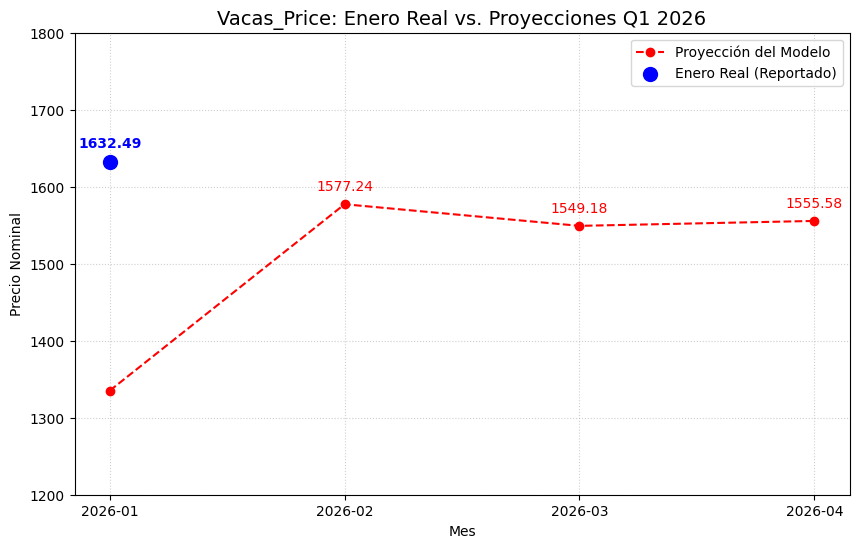

In [ ]:
import matplotlib.pyplot as plt

# Datos para la visualización
fechas_2026 = ['2026-01', '2026-02', '2026-03', '2026-04']
precios_reales = [1632.49, None, None, None]  # Solo enero es real
precios_predichos = [1335.16, 1577.24, 1549.18, 1555.58] # Enero (modelo) + Proyecciones

plt.figure(figsize=(10, 6))

# Graficar predicción del modelo (incluyendo el enero proyectado)
plt.plot(fechas_2026, precios_predichos, marker='o', linestyle='--', color='red', label='Proyección del Modelo')

# Graficar punto real de enero
plt.scatter(fechas_2026[0], precios_reales[0], color='blue', s=100, zorder=5, label='Enero Real (Reportado)')

# Anotaciones
plt.annotate(f'{precios_reales[0]}', (fechas_2026[0], precios_reales[0]), textcoords="offset points", xytext=(0,10), ha='center', color='blue', weight='bold')
for i, val in enumerate(precios_predichos[1:], 1):
    plt.annotate(f'{val}', (fechas_2026[i], val), textcoords="offset points", xytext=(0,10), ha='center', color='red')

plt.title('Vacas_Price: Enero Real vs. Proyecciones Q1 2026', fontsize=14)
plt.xlabel('Mes')
plt.ylabel('Precio Nominal')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.ylim(1200, 1800)
plt.show()